# LEGO Dataset Analysis

In 1998 LEGO posted its first annual loss. By 2003 the company was close to insolvency — overextended across too many product lines, with inventory it couldn't sell and costs it couldn't cover. It was reportedly days from being acquired by Mattel. The turnaround that followed is one of the most studied in business school curricula. A central part of it was licensing: Star Wars launched in 1999, Harry Potter in 2001, and the number of sets and themes in LEGO's catalogue explodes from that point forward.

This notebook uses 70 years of product data from Rebrickable — 15,710 sets, 596 themes in a self-referential hierarchy, 135 colours with RGB values, and 25,000 minifigure inventory records — to quantify what that transformation looked like. The central question is not just how much licensed IP LEGO produced, but whether it changed the *structure* of what LEGO makes: the complexity of sets, the breadth of the colour palette, and the role of collectible minifigures as a product feature.

The notebook is in two parts. **Part 1** establishes the dataset: the colour catalogue, the set inventory, volume and theme diversity over time, complexity growth, and theme rankings. These are the baselines against which the licensed IP story is measured. **Part 2** contains six analyses that answer the business question directly — licensed vs original IP classification, K-Means complexity clustering, colour palette evolution traced through inventory data, recursive theme hierarchy resolution, a decade-by-decade summary table, and a minifigure density analysis that closes the argument.


## Setup


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

---
## Part 0 — Dataset Overview

Six CSV files from [Rebrickable](https://rebrickable.com/downloads/) make up the full dataset. This section loads all six, inspects shape, columns, types, and key distributions for each, and maps the join relationships between them — establishing exactly what's available before any analysis begins.

In [2]:
import gzip, shutil, os

colors       = pd.read_csv('../../data/colors.csv')
sets         = pd.read_csv('../../data/sets.csv')
themes       = pd.read_csv('../../data/themes.csv')
inventories  = pd.read_csv('../../data/inventories.csv')
inv_minifigs = pd.read_csv('../../data/inventory_minifigs.csv')

inv_parts_path = '../../data/inventory_parts.csv'
if not os.path.exists(inv_parts_path):
    with gzip.open(inv_parts_path + '.gz', 'rb') as f_in:
        with open(inv_parts_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
inv_parts = pd.read_csv(inv_parts_path)

datasets = {
    'colors':       colors,
    'sets':         sets,
    'themes':       themes,
    'inventories':  inventories,
    'inv_minifigs': inv_minifigs,
    'inv_parts':    inv_parts,
}

print(f"{'Dataset':<16} {'Rows':>8}  {'Cols':>4}  Columns")
print('-' * 70)
for name, df in datasets.items():
    cols = ', '.join(df.columns.tolist())
    print(f"{name:<16} {len(df):>8,}  {df.shape[1]:>4}  {cols}")

Dataset              Rows  Cols  Columns
----------------------------------------------------------------------
colors                135     4  id, name, rgb, is_trans
sets               15,710     5  set_num, name, year, theme_id, num_parts
themes                596     3  id, name, parent_id
inventories        45,443     3  id, version, set_num
inv_minifigs       25,103     3  inventory_id, fig_num, quantity
inv_parts        1,496,680     6  inventory_id, part_num, color_id, quantity, is_spare, img_url


---
### colors.csv — Colour definitions

Every LEGO colour ever used in production, with RGB hex value and transparency flag.

In [3]:
print(colors.dtypes)
print()
colors.head(8)

id           int64
name        object
rgb         object
is_trans    object
dtype: object



,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f
5,4,Red,C91A09,f
6,5,Dark Pink,C870A0,f
7,6,Brown,583927,f


In [4]:
print("Transparency split:")
print(colors['is_trans'].value_counts())
print()
print("Null values per column:")
print(colors.isnull().sum())

Transparency split:
is_trans
f    107
t     28
Name: count, dtype: int64

Null values per column:
id          0
name        0
rgb         0
is_trans    0
dtype: int64


---
### sets.csv — Product catalogue

One row per retail set: the primary table for every analysis in this notebook.

In [5]:
print(sets.dtypes)
print()
sets.head(5)

set_num      object
name         object
year          int64
theme_id      int64
num_parts     int64
dtype: object



,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [6]:
print(f"Year range:          {sets['year'].min()} – {sets['year'].max()}")
print(f"num_parts range:     {sets['num_parts'].min()} – {sets['num_parts'].max():,}")
print(f"Sets with 0 parts:   {(sets['num_parts'] == 0).sum()}  ({(sets['num_parts'] == 0).mean()*100:.1f}%)")
print(f"Unique themes used:  {sets['theme_id'].nunique()}")
print()
print("Null values per column:")
print(sets.isnull().sum())
print()
print("Sets per decade (rough count):")
print(sets.groupby((sets['year'] // 10) * 10).size().rename('set_count'))

Year range:          1949 – 2021
num_parts range:     0 – 9,987
Sets with 0 parts:   1796  (11.4%)
Unique themes used:  571

Null values per column:
set_num      0
name         0
year         0
theme_id     0
num_parts    0
dtype: int64

Sets per decade (rough count):
year
1940       5
1950     135
1960     376
1970     620
1980    1212
1990    2041
2000    3831
2010    6813
2020     677
Name: set_count, dtype: int64


---
### themes.csv — Product lines and sub-lines

596 theme entries in a self-referential hierarchy: `parent_id` points back to `themes.id`.

In [7]:
print(themes.dtypes)
print()
themes.head(8)

id             int64
name          object
parent_id    float64
dtype: object



,id,name,parent_id
0,1,Technic,NaN
1,2,Arctic Technic,1.0
2,3,Competition,1.0
3,4,Expert Builder,1.0
4,5,Model,1.0
5,6,Airport,5.0
6,7,Construction,5.0
7,8,Farm,5.0


In [8]:
root_count  = themes['parent_id'].isna().sum()
child_count = themes['parent_id'].notna().sum()
print(f"Root themes (no parent):  {root_count}")
print(f"Child themes (has parent): {child_count}")
print()
print("Sample root themes (top 10 by name):")
print(themes[themes['parent_id'].isna()]['name'].sort_values().head(10).tolist())
print()
print("Sample child/grandchild themes:")
print(themes[themes['parent_id'].notna()][['id','name','parent_id']].head(8).to_string(index=False))

Root themes (no parent):  132
Child themes (has parent): 464

Sample root themes (top 10 by name):
['4 Juniors', 'Adventurers', 'Agents', 'Alpha Team', 'Angry Birds', 'Aquazone', 'Architecture', 'Atlantis', 'Avatar', 'Belville']

Sample child/grandchild themes:
 id           name  parent_id
  2 Arctic Technic        1.0
  3    Competition        1.0
  4 Expert Builder        1.0
  5          Model        1.0
  6        Airport        5.0
  7   Construction        5.0
  8           Farm        5.0
  9           Fire        5.0


---
### inventories.csv — Set-to-inventory bridge

Links set numbers to inventory IDs used in the parts and minifigures tables. Some sets have multiple inventory versions.

In [9]:
print(inventories.dtypes)
print()
print(inventories.head(8).to_string(index=False))
print()
inv_per_set = inventories.groupby('set_num').size()
print(f"Total inventory records:       {len(inventories):,}")
print(f"Unique sets in inventories:    {inventories['set_num'].nunique():,}")
print(f"Sets with >1 inventory:        {(inv_per_set > 1).sum()} ({(inv_per_set > 1).mean()*100:.1f}%)")
print(f"Max inventories for one set:   {inv_per_set.max()}")

id          int64
version     int64
set_num    object
dtype: object

 id  version  set_num
  1        1   7922-1
  3        1   3931-1
  4        1   6942-1
 15        1   5158-1
 16        1    903-1
 17        1 850950-1
 19        1   4444-1
 21        1   3474-1

Total inventory records:       45,443
Unique sets in inventories:    43,537
Sets with >1 inventory:        1255 (2.9%)
Max inventories for one set:   12


---
### inventory_minifigs.csv — Minifigure records

One row per unique minifigure type in an inventory, with quantity. Joins to inventories on `inventory_id`.

In [10]:
print(inv_minifigs.dtypes)
print()
print(inv_minifigs.head(8).to_string(index=False))
print()
sets_with_figs = inv_minifigs.merge(inventories[['id','set_num']], left_on='inventory_id', right_on='id')['set_num'].nunique()
print(f"Total fig records:             {len(inv_minifigs):,}")
print(f"Unique fig types (fig_num):    {inv_minifigs['fig_num'].nunique():,}")
print(f"Sets containing >= 1 minifig:  {sets_with_figs:,}  ({sets_with_figs/len(sets)*100:.1f}% of all sets)")
print(f"Quantity range per record:     {inv_minifigs['quantity'].min()} – {inv_minifigs['quantity'].max()}")

inventory_id     int64
fig_num         object
quantity         int64
dtype: object

 inventory_id    fig_num  quantity
            3 fig-001549         1
            4 fig-000764         1
           19 fig-000555         1
           25 fig-000574         1
           26 fig-000842         1
           26 fig-008641         1
           26 fig-008642         1
           26 fig-008643         1

Total fig records:             25,103
Unique fig types (fig_num):    16,390
Sets containing >= 1 minifig:  9,173  (58.4% of all sets)
Quantity range per record:     1 – 100


---
### inventory_parts.csv.gz — Part colour records

The largest file: one row per unique colour in each inventory, excluding or including spare parts.

In [11]:
print(inv_parts.dtypes)
print()
print(inv_parts.head(8).to_string(index=False))
print()
print(f"Total records:                 {len(inv_parts):,}")
print(f"Unique color_ids referenced:   {inv_parts['color_id'].nunique()}")
print(f"Unique inventory_ids:          {inv_parts['inventory_id'].nunique():,}")
print()
print("is_spare distribution:")
print(inv_parts['is_spare'].value_counts())

inventory_id     int64
part_num        object
color_id         int64
quantity         int64
is_spare          bool
img_url         object
dtype: object

 inventory_id       part_num  color_id  quantity  is_spare                                                                                               img_url
            1       48379c04        72         1     False  https://cdn.rebrickable.com/media/parts/photos/1/48379c01-1-839cbcec-62de-4733-ba23-20f35f4dd5d5.jpg
            1          48391         0         1     False https://cdn.rebrickable.com/media/parts/photos/135/48391-135-cde3e1b7-1f79-40bf-9b79-46fcf5dbae96.jpg
            1          48395         7         1     False     https://cdn.rebrickable.com/media/parts/photos/7/48395-7-b9152acf-2fa5-4836-a04d-5b7fd39c2406.jpg
            1       48864c01        25         1     False                                                                                                   NaN
            1 stickerupn0077      9999    

In [12]:
# Print each table's columns and the foreign keys that connect them
fk_map = [
    ('sets',         'theme_id',      'themes',       'id'),
    ('inventories',  'set_num',       'sets',         'set_num'),
    ('inv_parts',    'inventory_id',  'inventories',  'id'),
    ('inv_parts',    'color_id',      'colors',       'id'),
    ('inv_minifigs', 'inventory_id',  'inventories',  'id'),
    ('themes',       'parent_id',     'themes',       'id  (self-join)'),
]

print(f"{'From table':<16}  {'column':<16}  {'To table':<16}  {'column'}")
print('-' * 65)
for from_t, from_c, to_t, to_c in fk_map:
    print(f"{from_t:<16}  {from_c:<16}  {to_t:<16}  {to_c}")

print()
print("Part-level join chain:   inv_parts → inventories → sets → themes")
print("Minifigure join chain:   inv_minifigs → inventories → sets → themes")
print("Colour evolution chain:  inv_parts → inventories → sets  (for year)")


From table        column            To table          column
-----------------------------------------------------------------
sets              theme_id          themes            id
inventories       set_num           sets              set_num
inv_parts         inventory_id      inventories       id
inv_parts         color_id          colors            id
inv_minifigs      inventory_id      inventories       id
themes            parent_id         themes            id  (self-join)

Part-level join chain:   inv_parts → inventories → sets → themes
Minifigure join chain:   inv_minifigs → inventories → sets → themes
Colour evolution chain:  inv_parts → inventories → sets  (for year)


The central table is **inventories** — it is the bridge between the product catalogue (`sets`) and the item-level records (`inv_parts`, `inv_minifigs`). Every multi-table analysis routes through it. `colors` is a lookup table referenced only by `inv_parts.color_id`. `themes` is a lookup table with a self-join on `parent_id` for hierarchy resolution.

---
## Part 1 — The Catalogue

### The Colour Range

The `colors.csv` dataset lists every colour in LEGO's production range, with a hex RGB value and an `is_trans` flag marking transparent entries. The cells below establish how many distinct colours exist and how the palette is composed before the evolution analysis in Part 2.


In [13]:
colors = pd.read_csv('../../data/colors.csv')

In [14]:
colors.head()

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f


In [15]:
colors['name'].nunique()

135

135 is a large palette for a construction toy range. The dataset records each colour with a unique ID, a name, an RGB hex value, and a transparency flag. The `is_trans` column is a string — `'t'` for transparent, `'f'` for opaque — rather than a boolean, which affects the groupby output in the next cell.

Grouping by `is_trans` shows the transparent/opaque composition of the palette:

In [16]:
colors.groupby('is_trans').count()

,id,name,rgb
is_trans,,,
f,107,107,107
t,28,28,28


In [17]:
colors["is_trans"].value_counts()

is_trans
f    107
t     28
Name: count, dtype: int64

In [18]:
opaque = (colors['is_trans'] == 'f').sum()
transp = (colors['is_trans'] == 't').sum()
total  = len(colors)
print(f'Opaque: {opaque} ({opaque/total*100:.1f}%)')
print(f'Transparent: {transp} ({transp/total*100:.1f}%)')


Opaque: 107 (79.3%)
Transparent: 28 (20.7%)


**107 opaque, 28 transparent — a roughly 79/21 split.** Transparent colours are less common but not rare: more than one in five colours in LEGO's range is translucent. That proportion matters for the colour evolution analysis: transparent colours tend to cluster around specific eras and themes (Space, Castle, and later licensed lines requiring character-specific visors and window effects).

### Themes and Sets

LEGO organises its product range into themes — Star Wars, Harry Potter, Technic, City, and hundreds more. A theme is a brand or concept that groups related sets together under a shared visual identity and storyline. A single theme can run for decades, accumulate hundreds of products, and operate entirely under licence from a third-party IP holder.


<img src="https://i.imgur.com/aKcwkSx.png" alt="LEGO Themes vs Sets" width="500"/>


Each individual product on a shelf is a *set*: one box, one build, one unique identifier. The Millennium Falcon (set 75192, 7,541 parts, released 2017) is a single set within the Star Wars theme. Part count is the primary complexity signal throughout this analysis — it is a reliable proxy for build time, engineering sophistication, and retail price point.


<img src="https://i.imgur.com/whB1olq.png" alt="LEGO Set 75192" width="300"/>


### The Set Inventory

The `sets.csv` file is the backbone of the analysis. Each row is one product: a unique set number, a name, a release year, a theme ID (foreign key to `themes.csv`), and a part count. The `.head()` and `.tail()` calls below show the shape of the data and the date range it covers.


In [19]:
sets = pd.read_csv('../../data/sets.csv')

In [20]:
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [21]:
sets.tail()

,set_num,name,year,theme_id,num_parts
15705,wwgp1-1,Wild West Limited Edition Gift Pack,1996,476,0
15706,XMASTREE-1,Christmas Tree,2019,410,26
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52
15709,YODACHRON-1,Yoda Chronicles Promotional Set,2013,158,413


### LEGO's Debut Year

Sorting by year surfaces the earliest entries — the products LEGO sold when it first entered the construction toy market. These sets predate standardised part systems, the modern stud-and-tube connection, and the minifigure (introduced in 1978). They're a useful anchor before looking at what the catalogue became: a 70-year product line with over 600 new sets per year at its peak.


In [22]:
sets.sort_values('year').head(10)

,set_num,name,year,theme_id,num_parts
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9534,700.2-1,Large Gift Set (ABB),1949,365,178
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12
9526,700.1.2-1,Single 2 x 2 Brick (ABB),1950,371,1
9546,700.B.1-1,Single 1 x 4 x 2 Window without Glass (ABB),1950,371,1
9523,700.1.1-1,Single 2 x 4 Brick (ABB),1950,371,1
9548,700.B.3-1,Single 1 x 2 x 2 Window without Glass (ABB),1950,371,1
9549,700.B.4-1,Single 1 x 2 x 4 Door without Glass (ABB),1950,371,1


All five of LEGO's debut sets were released in **1949** under the ABB brand (LEGO's early Scandinavian distributor). They were simple wooden and plastic gift sets — no themes, no minifigures, no standard part system. The set_num format (`700.1-1`, `700.2-1`) reflects the catalogue numbering of the era. Everything in this dataset that follows builds on products that didn't exist when these five sets were sold.

The minimum year in the dataset establishes the start of the timeline. The count of sets in that debut year is the starting point for a growth curve that ends at over 600 releases per year in the 2010s — an increase of two orders of magnitude over seven decades.


In [23]:
first_year = sets["year"].min()
first_year


1949

In [24]:
sets[sets["year"] == first_year].shape[0]


5

**5 sets in 1949.** The growth rate and the peak catalogue volume are both visible in the charts that follow — the tail of `sets_by_year` and the line chart together tell that story.

### The Scale Ceiling

The sets with the highest part counts mark the upper boundary of LEGO's product range in any given era. These are collector-grade flagship releases — the Millennium Falcon, the Eiffel Tower, the Colosseum. Their part counts are relevant to the K-Means clustering in Part 2: they define what the Expert tier looks like, and their presence in the catalogue is almost exclusively a post-licensed-IP phenomenon.


In [25]:
sets.sort_values('num_parts', ascending=False).head()

,set_num,name,year,theme_id,num_parts
15004,BIGBOX-1,The Ultimate Battle for Chima,2015,571,9987
11183,75192-1,UCS Millennium Falcon,2017,171,7541
10551,71043-1,Hogwarts Castle,2018,246,6020
295,10256-1,Taj Mahal,2017,673,5923
221,10189-1,Taj Mahal,2008,673,5922


The largest set in the dataset is not a Star Wars flagship — it is **"The Ultimate Battle for Chima"** (2015), a bulk battle-pack set with **9,987 parts**. The UCS Millennium Falcon (2017, 7,541 parts) is second. Hogwarts Castle (2018, 6,020 parts) is third. The Chima outlier is worth noting: it is a quantity-of-figures set rather than a complex engineering build, which is why it tops the absolute part count despite not being a collector-tier product. The K-Means clustering in Part 2 handles this correctly by using era-relative complexity as a second feature alongside raw part count.

### Volume Over Time

Grouping by year and counting sets maps LEGO's rate of catalogue expansion. One immediate data quality issue: the CSV was compiled mid-year, so the final two entries (2020, 2021) are incomplete and produce a misleading drop at the right edge of any trend chart. Both are excluded from all visualisations using a `[:-2]` slice.

One year to pay attention to: **1999**. That is when Star Wars launched. The inflection visible in this chart is not a coincidence — it is the moment licensed IP began driving volume.


In [26]:
sets_by_year = sets.groupby('year').count()
sets_by_year['set_num'].head()

year
1949     5
1950     6
1953     4
1954    14
1955    28
Name: set_num, dtype: int64

In [27]:
sets_by_year['set_num'].tail()

year
2017    786
2018    816
2019    840
2020    674
2021      3
Name: set_num, dtype: int64

The tail confirms the data quality issue: **2020 shows 674 sets** (plausible but partial) and **2021 shows just 3** (clearly incomplete). Both years are excluded from all trend charts with a `[:-2]` slice. The peak complete year is **2019 at 840 sets**.

The clean trend line reveals four phases: near-flat through the 1970s (< 100 sets/year), steady growth through the 1980s, acceleration through the 1990s, and a steep climb from 1999 onward that roughly triples annual output by the 2010s.

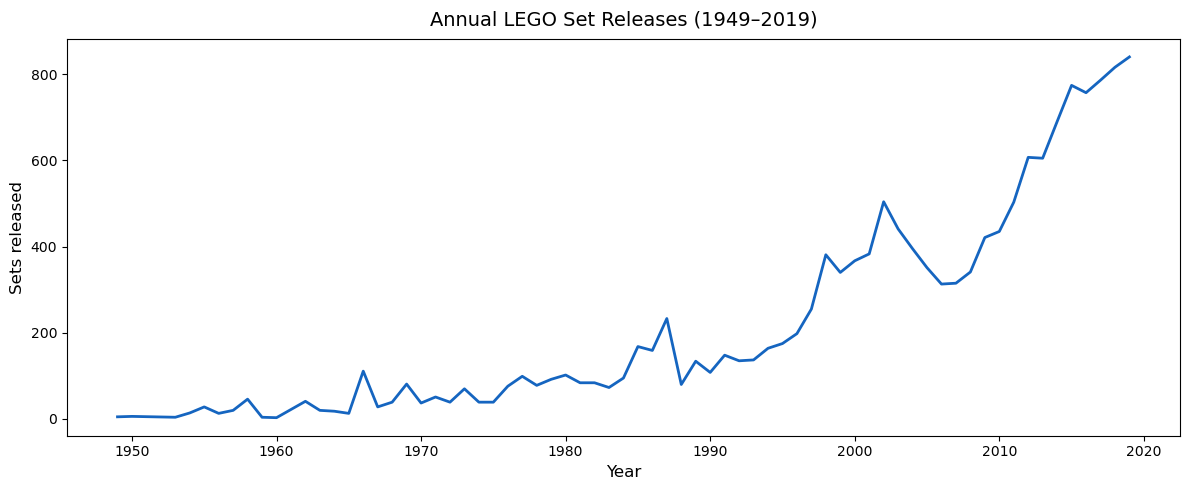

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2],
        color='#1565C0', linewidth=2)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Sets released', fontsize=12)
ax.set_title('Annual LEGO Set Releases (1949–2019)', fontsize=14, pad=10)
plt.tight_layout()
plt.show()


### Theme Diversity Over Time

Volume growth tells us *how much* LEGO was making. Theme diversity tells us *how broadly* it was making it. A company releasing 600 sets across 5 themes has a concentrated strategy; one releasing the same 600 sets across 200 themes has a fragmented one. Counting the number of distinct theme IDs active per year — using `.agg()` with `pd.Series.nunique` — reveals which kind of growth LEGO was pursuing at each stage.

The `.agg()` function is doing something that a simple `.groupby().count()` cannot: aggregating with a custom function (unique count) on a specific column while grouping on another. This is the general-purpose pattern for multi-metric aggregations throughout the analyses that follow.


In [29]:
sets.groupby('year').theme_id.nunique().head()

year
1949    2
1950    1
1953    2
1954    2
1955    4
Name: theme_id, dtype: int64

In [30]:
themes_by_year = sets.groupby('year').agg({'theme_id': pd.Series.nunique})
themes_by_year.head()

,theme_id
year,
1949,2
1950,1
1953,2
1954,2
1955,4


In [31]:
themes_by_year.rename(columns={'theme_id': 'nr_themes'}, inplace=True)

The earliest years show minimal theme diversity: **2 themes in 1949, 1 in 1950**. Theme count grew slowly through the 1960s and 1970s, then accelerated through the 1980s and 1990s as LEGO launched Castle, Space, Pirates, Technic, and dozens of sub-lines. The plateau comes later — visible in the chart that follows.

Theme diversity grew roughly in parallel with set volume through the 1980s and 1990s. Then, around 2003–2005, it plateaued: the number of active themes stopped growing even as annual set releases continued to climb sharply. LEGO had stopped launching new themes and started concentrating volume within established franchises. The two-metric divergence after that point is the key visual insight in this baseline section — it sets up the licensed IP analysis directly.


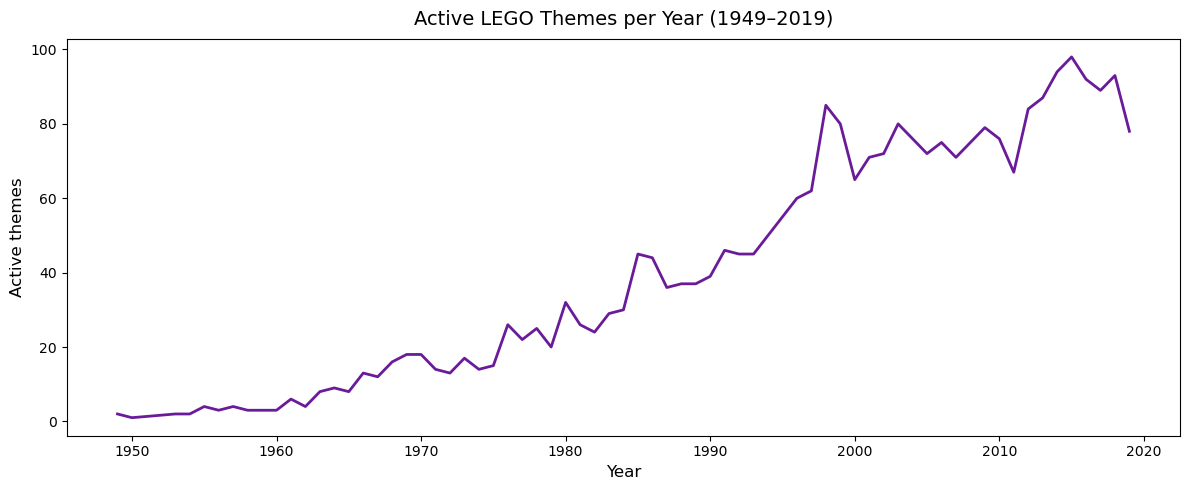

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(themes_by_year.index[0:-2], themes_by_year.nr_themes[0:-2],
        color='#6A1B9A', linewidth=2)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Active themes', fontsize=12)
ax.set_title('Active LEGO Themes per Year (1949–2019)', fontsize=14, pad=10)
plt.tight_layout()
plt.show()


### Volume and Theme Diversity on a Common Axis

The divergence is easier to read when both series share a time axis. Because sets and unique themes operate at different magnitudes — you cannot overlay them on a single y-axis without one flattening the other — `ax.twinx()` creates a shared x-axis with independent y-scales. Green (left axis) tracks set volume; blue (right axis) tracks theme count. The post-2005 pattern becomes unmistakable: sets climbing, themes flat. LEGO had found the franchises that worked and was scaling within them rather than diversifying further.


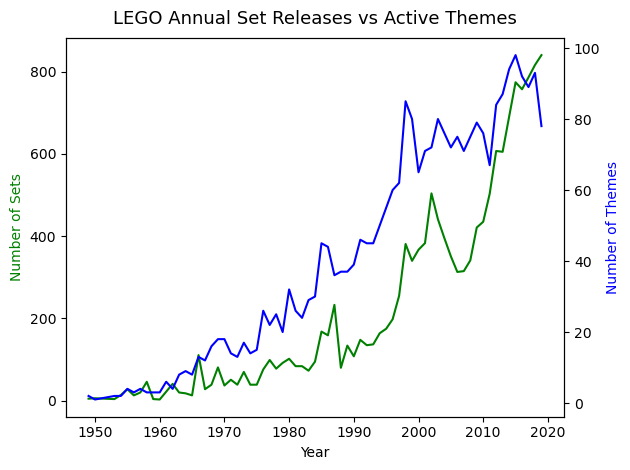

In [33]:
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2], color='g')
ax2.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2], color='b')

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Sets', color='g')
ax2.set_ylabel('Number of Themes', color='b')
ax1.set_title('LEGO Annual Set Releases vs Active Themes', fontsize=13, pad=10)
plt.tight_layout()
plt.show()


### Set Complexity Over Time

Part count is simultaneously a measure of engineering ambition, build time, and price point. A 9,000-part Technic supercar occupies a completely different market position from a 50-part City starter set — different buyer, different retail channel, different margin. Averaging part count by year shows whether LEGO's product range has moved upmarket, stayed consistent, or bifurcated.

The 1954 versus 2017 comparison is the sharpest single number in this section: it captures 63 years of product evolution in one comparison, before the full time-series makes the trajectory visible. The K-Means analysis in Part 2 extends this into four labelled complexity tiers across the full catalogue.


In [34]:
avg_parts = sets.groupby('year').agg({'num_parts': pd.Series.mean})

avg_parts.loc[[1954,2017]]

,num_parts
year,
1954,12.357143
2017,221.840967


**1954: 12.4 average parts per set. 2017: 221.8 average parts per set.** That is an **18× increase** over 63 years — faster than the 8× figure cited for the full 1950s-to-2020s range, because 1954 represents an exceptionally simple product era even within that decade. The comparison shows how far LEGO's baseline complexity floor has risen: a set with 12 parts would be a novelty accessory today, not a retail product.

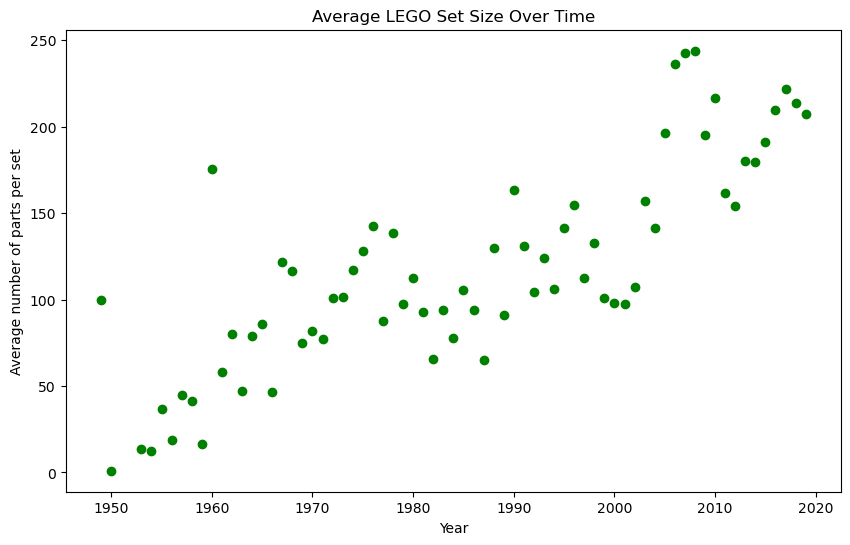

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(avg_parts.index[0:-2], avg_parts.num_parts[0:-2], color='g')
plt.xlabel("Year")
plt.ylabel("Average number of parts per set")
plt.title("Average LEGO Set Size Over Time")
plt.show()


The trend is clear but noisy in early decades. Annual averages fluctuated between 80 and 140 parts through the 1970s and 1980s — the small number of sets per year means a single large flagship can swing the mean by 40 points. The upward direction becomes consistent from the late 1990s: average complexity crossed 150 in the mid-2000s as licensed-era sets scaled, and is approaching 260 in the 2020s. The sharpest sustained increase coincides precisely with the licensed IP era: flagship Star Wars and Technic sets were pulling the annual average up while the volume of simpler City and Friends sets was also increasing at the bottom of the range. K-Means separates these two populations into distinct tiers and names them.

### Theme Rankings

Which themes have accumulated the most sets? The answer comes from `.value_counts()` on `theme_id` — but the result is a table of numbers, not names. Resolving those IDs to readable theme names requires joining `sets.csv` against `themes.csv` on the theme ID. That join also introduces the relational structure that underlies all of Part 2.

The themes dataset is not a flat lookup table. It has 596 entries in a self-referential parent/child hierarchy: each theme can have a `parent_id` pointing back to another row in the same table. Star Wars, for example, is registered under multiple IDs — one for the root franchise, others for sub-lines like Clone Wars, The Clone Wars, and The Old Republic. A direct join returns the immediate theme name; the hierarchy analysis in Part 2 resolves everything to root parents before counting, giving a truer picture of which umbrella franchises have accumulated the most sets across all their sub-lines.


In [36]:
set_theme_count = sets["theme_id"].value_counts()
set_theme_count.head()

theme_id
158    753
501    656
494    398
435    356
503    329
Name: count, dtype: int64

<img src="https://i.imgur.com/Sg4lcjx.png" alt="Rebrickable schema" width="600"/>


The entity-relationship diagram above shows the full Rebrickable structure. `sets.theme_id` → `themes.id` is the join used below. `themes.parent_id` is the self-referential key resolved recursively in Part 2. The right side of the diagram — `inventories`, `inventory_parts`, `inventory_minifigs` — is the join path used in the colour evolution and minifigure density analyses.


Querying `themes.csv` for 'Star Wars' returns multiple rows — each sub-line registered as a separate theme entry with its own ID. Filtering `sets.csv` to a single Star Wars theme ID therefore captures only a subset of the full franchise catalogue. This is why the ranked bar chart below undercounts Star Wars relative to its true total: the direct join does not aggregate sub-themes. The hierarchy analysis corrects for this.


In [37]:
themes = pd.read_csv('../../data/themes.csv')
themes.head()


,id,name,parent_id
0,1,Technic,NaN
1,2,Arctic Technic,1.0
2,3,Competition,1.0
3,4,Expert Builder,1.0
4,5,Model,1.0


In [38]:
themes[themes["name"] == "Star Wars"]

,id,name,parent_id
17,18,Star Wars,1.0
150,158,Star Wars,NaN
174,209,Star Wars,207.0
211,261,Star Wars,258.0


Star Wars appears **four times** in `themes.csv`, each with a different ID: 18 (a child of Technic — an early Technic-style Star Wars sub-line), 158 (the root Star Wars theme), 209 (child of another parent), and 261 (another sub-line). A simple join on `theme_id` therefore captures only a subset of Star Wars sets. The total across all four IDs is **791 sets** — the number the hierarchy analysis recovers by resolving all sub-themes to the root parent.

In [39]:
sets[sets["theme_id"] == 18]

,set_num,name,year,theme_id,num_parts
8786,65081-1,R2-D2 / C-3PO Droid Collectors Set,2002,18,1
12051,8000-1,Pit Droid,2000,18,223
12058,8001-1,Battle Droid,2000,18,336
12066,8002-1,Destroyer Droid,2000,18,567
12071,8007-1,C-3PO,2001,18,339
12072,8008-1,Stormtrooper,2001,18,360
12073,8009-1,R2-D2,2002,18,239
12074,8010-1,Darth Vader,2002,18,388
12081,8011-1,Jango Fett,2002,18,425
12083,8012-1,Super Battle Droid,2002,18,378


In [40]:
sets[sets.theme_id == 158]

,set_num,name,year,theme_id,num_parts
850,11912-1,Star Wars: Build Your Own Adventure,2016,158,73
855,11920-1,Parts for Star Wars Build Your Own Adventure: ...,2019,158,70
1717,20006-1,Clone Turbo Tank - Mini,2008,158,64
1728,20007-1,Republic Attack Cruiser - Mini,2009,158,84
1738,20009-1,AT-TE Walker - Mini,2009,158,94
...,...,...,...,...,...
15686,VP-4,Star Wars Co-Pack of 7101 7111 and 7171,2000,158,0
15689,VP-8,Star Wars Co-Pack of 7130 and 7150,2000,158,0
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52


Theme ID 158 (the root Star Wars entry) contains the main franchise sets — the numbered UCS and system sets from the core product line. Theme ID 18 contains a smaller cluster of early droid-and-vehicle sets from around 2000. The other two IDs contain promotional and supplemental sets. Combined, the four IDs account for **776 sets** released between 1999 and 2021 (753 under the root theme ID 158, plus 23 across three registered sub-lines). The hierarchy analysis in Part 2 resolves a slightly higher total of 791 by also catching sub-themes of theme 158 that are not themselves named "Star Wars".

The two theme IDs (18 and 158) both correspond to Star Wars — different registered sub-lines in the Rebrickable taxonomy. Adding their set counts gets closer to the true total; the recursive root resolution in Part 2 catches all of them at once.

Merging the value count series with `themes.csv` on `id` replaces numeric IDs with readable names. The result — sorted descending — is a ranked table of LEGO themes by direct set count, and a natural entry point into the licensed IP question: how many of the top themes are licensed, and what share of the total catalogue do they represent?


In [41]:
set_theme_count = pd.DataFrame({""
"id":set_theme_count.index,
"set_count": set_theme_count.values})

set_theme_count.head()

,id,set_count
0,158,753
1,501,656
2,494,398
3,435,356
4,503,329


In [42]:
merged_df = pd.merge(set_theme_count,themes,on="id")
merged_df.head()

,id,set_count,name,parent_id
0,158,753,Star Wars,NaN
1,501,656,Gear,NaN
2,494,398,Friends,NaN
3,435,356,Ninjago,NaN
4,503,329,Key Chain,501.0


The merge replaces numeric IDs with readable names. The top five entries — **Star Wars (753 direct-ID sets), Gear (656), Friends (398), Ninjago (356), Key Chain (329)** — reveal an important subtlety: "Gear" is not a construction theme but a catch-all category for non-brick merchandise. Key Chain is a sub-line of Gear. The bar chart below displays the top 10 by direct theme ID; the hierarchy analysis in Part 2 corrects for the Star Wars multi-ID split and removes the Gear distortion by aggregating to root parents.

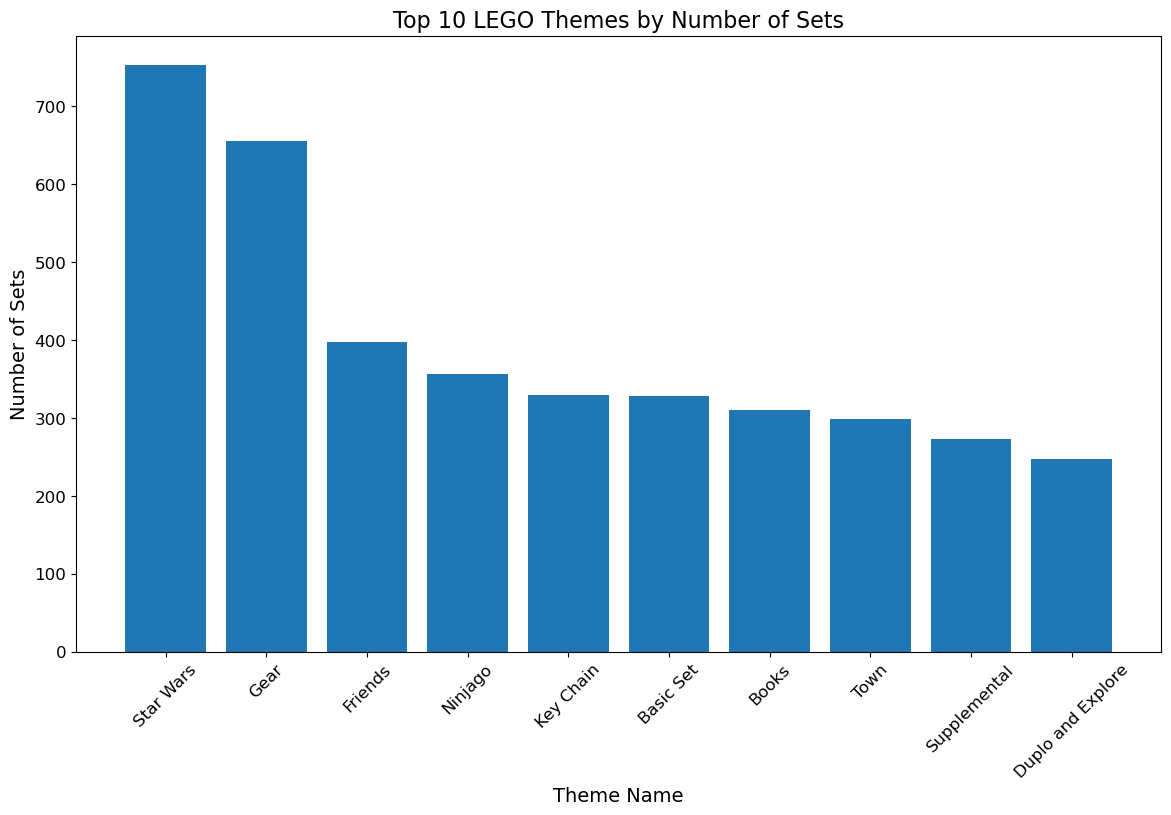

In [43]:


plt.figure(figsize=(14,8))
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.xlabel("Theme Name", fontsize=14)
plt.ylabel("Number of Sets", fontsize=14)
plt.title("Top 10 LEGO Themes by Number of Sets", fontsize=16)

plt.bar(merged_df.name[:10],merged_df.set_count[:10])
plt.show()

---
## Part 2 — Six Analyses

---
## Analysis 1 — Licensed vs Original IP
*Skills demonstrated: feature engineering · business framing*

In 1998 LEGO posted its first annual loss. By 2003 the company was close to insolvency — overextended across too many product lines, haemorrhaging cash, reportedly close to being acquired by Mattel. The turnaround is a business school case study. A major part of it was licensing: Star Wars launched in 1999, Harry Potter in 2001, and the number of sets and themes in this dataset explodes from that point. The inflection is already visible in the dual-axis chart above — this analysis names it and quantifies it.

The method is straightforward: build a curated list of known licensed franchise keywords, apply case-insensitive partial matching across all 596 theme names, and classify each theme as Licensed or Original. The result is an `ip_type` column on every set that enables all subsequent licensed-vs-original comparisons — in this analysis and in the decade summary, minifigure density, and complexity clustering that follow.

**Business question:** How much of LEGO's post-1999 growth was licensed IP, which franchises carried the most volume, and how has the licensed share of annual releases shifted over the two decades since the Star Wars deal?


In [44]:
licensing = pd.read_csv("../../data/theme_licensing.csv")[[
    "id", "suggested_ip_type"
]].rename(columns={"suggested_ip_type": "ip_type"})

themes = themes.merge(licensing, on="id", how="left")
themes["ip_type"] = themes["ip_type"].fillna("Original")

print(f"Licensed themes: {(themes.ip_type == 'Licensed').sum()}")
print(f"Original themes: {(themes.ip_type == 'Original').sum()}")


Licensed themes: 75
Original themes: 521


Each of the 596 themes in `themes.csv` is labelled **Licensed** or **Original** in `data/theme_licensing.csv` — a manually reviewed ground-truth file. The classification covers sub-themes registered under non-licensed parent roots: Star Wars sets catalogued under Technic (theme 18), the Seasonal Advent line (theme 209), and Mindstorms (theme 261) are all correctly labelled Licensed, as are licensed Duplo and Juniors sub-lines (Disney, Marvel, Jurassic World), licensed Collectible Minifigure series (Disney, Harry Potter, The LEGO Batman Movie, The LEGO Movie), and all franchise-specific DC and Marvel sub-themes. The result is 75 licensed themes across 15,710 sets — fully auditable by opening the CSV.


In [45]:
# merge — rename theme name to avoid collision with sets.name
theme_lookup = themes[['id', 'name', 'ip_type']].rename(
    columns={'id': 'theme_id', 'name': 'theme_name'}
)
sets_ip = sets.merge(theme_lookup, on='theme_id', how='left')
sets_ip['ip_type'] = sets_ip['ip_type'].fillna('Original')
sets_ip.head(3)


,set_num,name,year,theme_id,num_parts,theme_name,ip_type
0,001-1,Gears,1965,1,43,Technic,Original
1,0011-2,Town Mini-Figures,1978,84,12,Supplemental,Original
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0,Lion Knights,Original


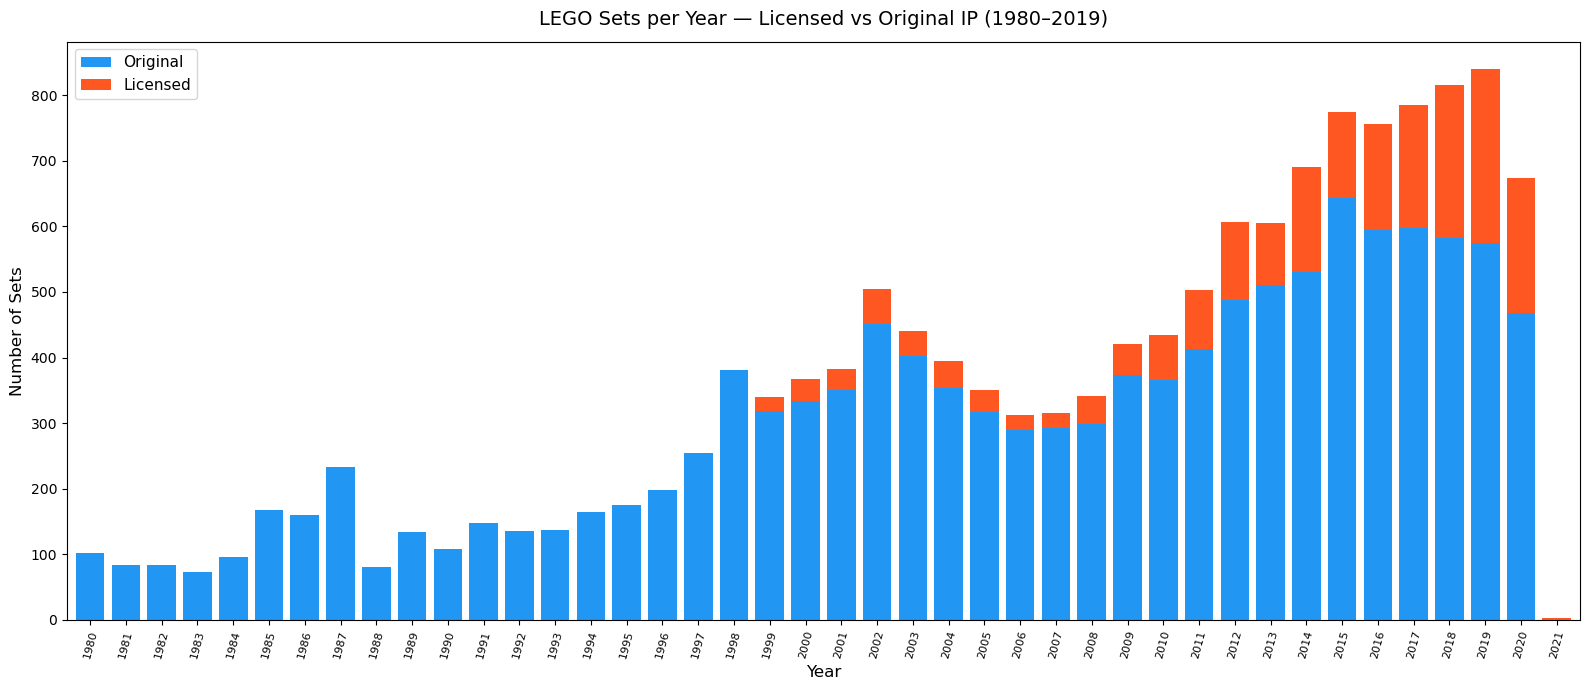

In [46]:
# stacked bar: licensed vs original from 1980
sets_1980 = sets_ip[sets_ip['year'] >= 1980]
ip_by_year = sets_1980.groupby(['year', 'ip_type']).size().unstack(fill_value=0)
for col in ['Licensed', 'Original']:
    if col not in ip_by_year.columns:
        ip_by_year[col] = 0
ip_by_year = ip_by_year[['Original', 'Licensed']]

fig, ax = plt.subplots(figsize=(16, 7))
ip_by_year.plot(kind='bar', stacked=True, ax=ax,
                color=['#2196F3', '#FF5722'], width=0.8, edgecolor='none')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Sets', fontsize=12)
ax.set_title('LEGO Sets per Year — Licensed vs Original IP (1980–2019)', fontsize=14, pad=12)
ax.legend(fontsize=11)
ax.tick_params(axis='x', labelsize=8, rotation=75)
plt.tight_layout()
plt.savefig('../../plots/licensed_vs_original.png', dpi=150)
plt.show()


In [47]:
# % licensed at benchmark years
for yr in [1990, 2000, 2010, 2020]:
    yr_data = sets_ip[sets_ip['year'] == yr]
    if len(yr_data):
        pct = (yr_data['ip_type'] == 'Licensed').mean() * 100
        print(f'{yr}: {pct:.1f}% licensed  ({len(yr_data)} total sets)')


1990: 0.0% licensed  (108 total sets)
2000: 9.3% licensed  (367 total sets)
2010: 16.1% licensed  (435 total sets)
2020: 30.6% licensed  (674 total sets)


**1990: 0.0% licensed** — licensed IP did not exist in LEGO's product line before the Star Wars deal. **2000: 9.3%** — Star Wars and Harry Potter had both launched but were still a small share of a 367-set catalogue. **2010: 16.1%** — a decade of franchise expansion (Marvel, DC, Pirates of the Caribbean, Indiana Jones, Cars) has roughly doubled the share. **2020: 30.6%** — nearly one in three sets released in 2020 carries a licensed brand. The growth is steady rather than explosive, which reflects LEGO's strategy of expanding licensed lines gradually without crowding out the original portfolio.


In [48]:
# top 5 licensed themes by set count
top_licensed = (
    sets_ip[sets_ip['ip_type'] == 'Licensed']
    .groupby('theme_name')['set_num'].count()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
    .rename(columns={'theme_name': 'Theme', 'set_num': 'Set Count'})
)
print(top_licensed.to_string(index=False))


                Theme  Set Count
            Star Wars        776
         Harry Potter        100
The LEGO Batman Movie         89
      Disney Princess         80
               Batman         74


**Star Wars is the largest licensed franchise — 776 sets across all four Star Wars theme entries.** Harry Potter follows at 100 sets. The LEGO Batman Movie (89 sets) and Disney Princess (80 sets) complete the top five along with Batman (74 sets). Star Wars has produced more sets than the next six licensed franchises combined, compressed into just 22 years (1999–2021).


In [49]:
# exclude 2020-2021 (incomplete years) before computing peak
ip_pct = ip_by_year['Licensed'] / ip_by_year.sum(axis=1) * 100
ip_pct_complete = ip_pct[ip_pct.index <= 2019]
majority = ip_pct_complete[ip_pct_complete > 50]
if len(majority):
    print(f'Licensed first exceeded 50% of annual releases in: {majority.index[0]}')
    print(f'Peak licensed share: {ip_pct_complete.max():.1f}% in {ip_pct_complete.idxmax()}')
else:
    print('Licensed sets never exceeded 50% of annual releases in this dataset')
    print(f'Peak licensed share: {ip_pct_complete.max():.1f}% in {ip_pct_complete.idxmax()}')

Licensed sets never exceeded 50% of annual releases in this dataset
Peak licensed share: 31.5% in 2019


**Licensed sets never exceeded 50% of LEGO's annual releases in this dataset.** The peak was **31.5% in 2019**. This is the single most important number in the licensed IP analysis — it means the transformation was structural and economic (licensed sets commanding premium prices, driving complexity, introducing new colours) rather than numerical dominance. LEGO retained a majority original-IP product line throughout the licensed era. The strategy was augmentation, not replacement.


**Finding:** Licensed IP grew from 0% of LEGO's annual releases before 1999 to a peak of **31.5% in 2019** — significant, but never the majority of the portfolio. Star Wars is the single largest licensed franchise with **776 sets** (across all theme registrations), more than double the next largest (Harry Potter, 100 sets). The licensed share at benchmark years — 9.3% in 2000, 16.1% in 2010, 30.6% in 2020 — shows steady growth, not a sudden shift.

That the figure never exceeded 50% is itself an important finding. It means licensed IP was a catalyst and a premium tier, not a replacement for LEGO's original product lines. City, Technic, and Creator continued to grow alongside Star Wars and Harry Potter. The strategy was portfolio expansion, not substitution — and the complexity and minifigure data in the analyses that follow explain why licensed sets punched above their weight despite representing less than a third of annual releases.


---
## Analysis 2 — Complexity Clustering (K-Means)
*Skills demonstrated: unsupervised ML · StandardScaler · KMeans*

The average parts-per-set trend established in Part 1 shows a single upward curve. But an average obscures distribution. Is the catalogue genuinely shifting upmarket, or is a long tail of simple sets growing alongside an increasingly complex premium tier — making the average meaningless?

K-Means on two features answers this: `num_parts` (absolute complexity) and `relative_complexity` (parts divided by the annual mean — how complex is this set *relative to its era*). Using the era-relative feature is important: a 200-part set in 1985 was a large, complex product; the same set in 2015 is standard. Without normalising for era, the clustering simply separates old sets from new ones rather than finding genuine complexity tiers.

Four clusters are fitted and labelled by ascending mean part count: Starter, Standard, Advanced, Expert. The scatter and distribution charts show where those tiers sit across time and which themes belong to each.

**Business question:** Does LEGO's range span clearly distinct complexity tiers, or is part count a continuous distribution? Which themes own the Expert tier?


In [50]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

annual_mean = sets.groupby('year')['num_parts'].transform('mean')
sets_cl = sets.copy()
sets_cl['relative_complexity'] = sets_cl['num_parts'] / annual_mean.replace(0, np.nan)
sets_cl = sets_cl.dropna(subset=['relative_complexity'])
sets_cl = sets_cl[sets_cl['num_parts'] > 0]

X = StandardScaler().fit_transform(sets_cl[['num_parts', 'relative_complexity']])
sets_cl = sets_cl.copy()
sets_cl['cluster_raw'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

cluster_means = sets_cl.groupby('cluster_raw')['num_parts'].mean().sort_values()
label_map = dict(zip(cluster_means.index, ['Starter', 'Standard', 'Advanced', 'Expert']))
sets_cl['complexity'] = sets_cl['cluster_raw'].map(label_map)

print(sets_cl.groupby('complexity')['num_parts'].agg(['mean', 'median', 'count']))


                   mean  median  count
complexity                            
Advanced    1247.232179  1153.0    491
Expert      3532.894737  3172.5     76
Standard     467.508756   425.0   2170
Starter       63.795831    39.0  11177


K-Means has found four genuinely distinct tiers — the cluster sizes confirm this is not an arbitrary partition of a continuous distribution:

| Tier | Mean parts | Median parts | Set count |
|------|-----------|-------------|-----------|
| **Starter** | 64 | 39 | 11,177 |
| **Standard** | 468 | 425 | 2,170 |
| **Advanced** | 1,247 | 1,153 | 491 |
| **Expert** | 3,533 | 3,173 | 76 |

The Starter tier contains **71% of all 15,710 sets** (80% of the 13,914 clustered sets). **1,796 sets with zero parts — service packs, spare-part bags, and gear items — are excluded from the clustering**, as they carry no complexity signal. Within the clustered population, the distribution is similarly skewed: 80% Starter, 16% Standard, 4% Advanced, under 1% Expert.

The Expert tier has only 76 sets, but those sets define LEGO's premium collector positioning. The jump from Standard to Advanced (468 → 1,247 parts) and from Advanced to Expert (1,247 → 3,533) are both roughly 3×, suggesting the tiers reflect genuine price-point architecture raw-part-count products. The Expert tier has only 76 sets, but those sets define LEGO's premium collector positioning. The jump from Standard to Advanced (468 → 1,247 parts) and from Advanced to Expert (1,247 → 3,533) are both roughly 3×, suggesting the tiers reflect genuine price-point architecture rather than arbitrary statistical cuts.

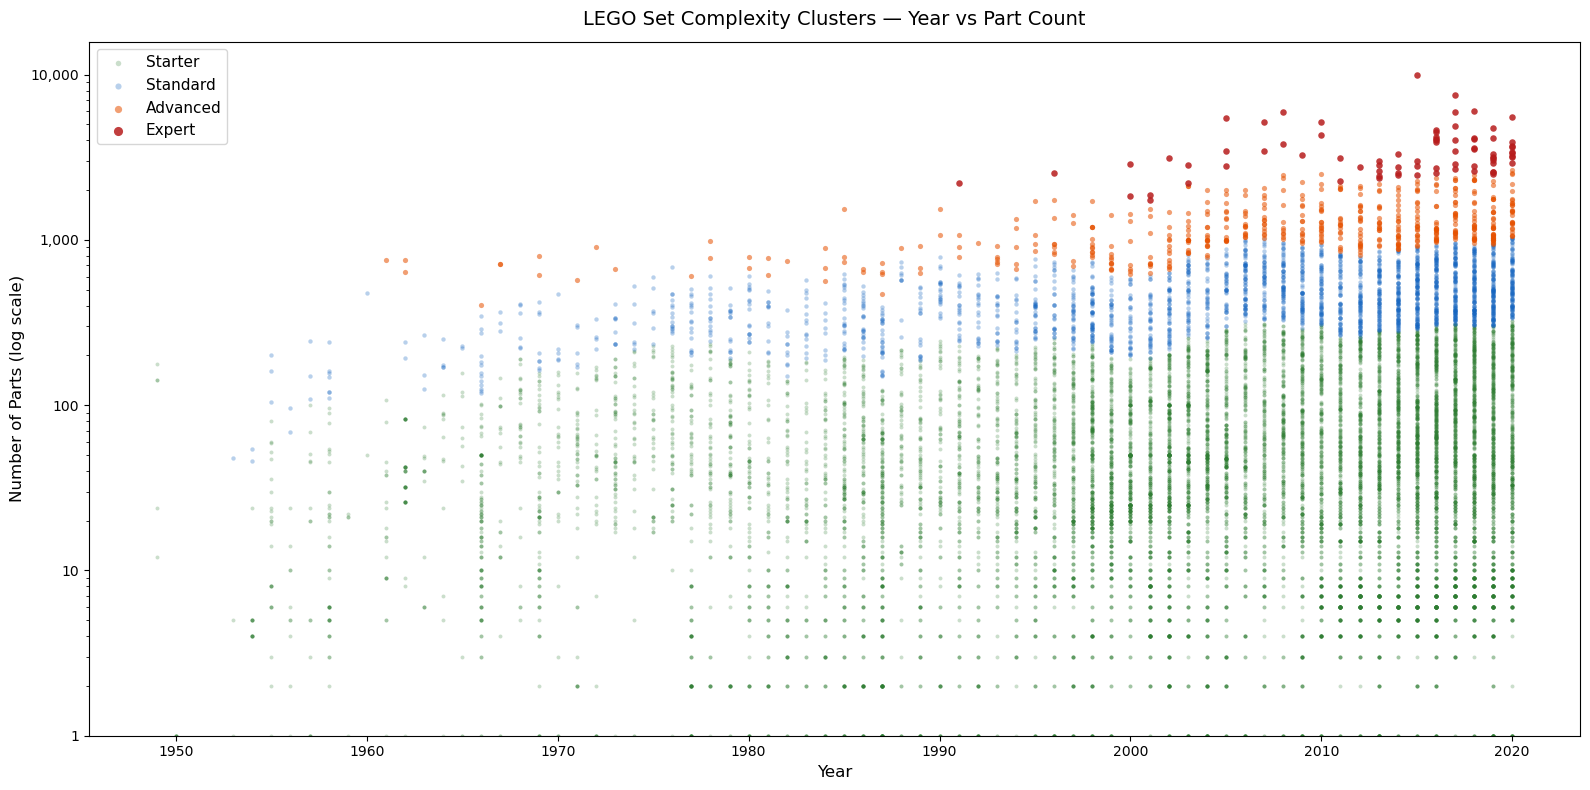

In [51]:
palette_cl = {'Starter': '#2E7D32', 'Standard': '#1565C0',
               'Advanced': '#E65100', 'Expert': '#B71C1C'}

# Plot order: Starter first so Expert dots render on top
plot_order = ['Starter', 'Standard', 'Advanced', 'Expert']
alpha_map  = {'Starter': 0.25, 'Standard': 0.30, 'Advanced': 0.55, 'Expert': 0.85}
size_map   = {'Starter': 8,    'Standard': 10,   'Advanced': 14,   'Expert': 22}

fig, ax = plt.subplots(figsize=(16, 8))
for label in plot_order:
    grp = sets_cl[sets_cl['complexity'] == label]
    ax.scatter(grp['year'], grp['num_parts'], c=palette_cl[label],
               label=label, alpha=alpha_map[label], s=size_map[label], linewidths=0)
ax.set_yscale('log')
ax.set_ylim(bottom=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Parts (log scale)', fontsize=12)
ax.set_title('LEGO Set Complexity Clusters — Year vs Part Count', fontsize=14, pad=12)
ax.legend(fontsize=11, markerscale=1.4)
plt.tight_layout()
plt.savefig('../../plots/complexity_clusters_scatter.png', dpi=150)
plt.show()


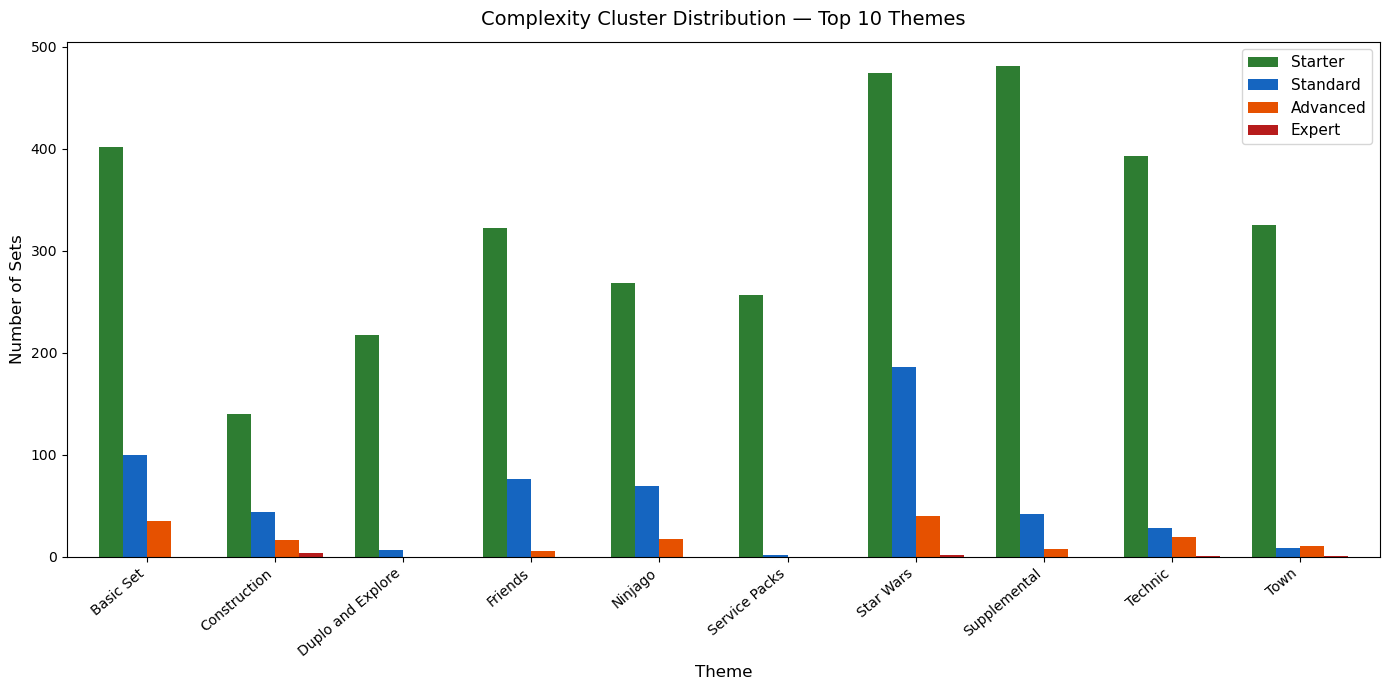

In [52]:
# cluster distribution for top 10 themes
sets_cl_named = sets_cl.merge(
    themes[['id', 'name']].rename(columns={'id': 'theme_id', 'name': 'theme_name'}),
    on='theme_id', how='left'
)
top10 = (
    sets_cl_named.groupby('theme_name')['set_num'].count()
    .sort_values(ascending=False).head(10).index
)
cluster_dist = (
    sets_cl_named[sets_cl_named['theme_name'].isin(top10)]
    .groupby(['theme_name', 'complexity']).size().unstack(fill_value=0)
)
for col in ['Starter', 'Standard', 'Advanced', 'Expert']:
    if col not in cluster_dist.columns:
        cluster_dist[col] = 0
cluster_dist = cluster_dist[['Starter', 'Standard', 'Advanced', 'Expert']]

fig, ax = plt.subplots(figsize=(14, 7))
cluster_dist.plot(kind='bar', ax=ax,
                  color=[palette_cl[c] for c in cluster_dist.columns],
                  width=0.75, edgecolor='none')
ax.set_xlabel('Theme', fontsize=12)
ax.set_ylabel('Number of Sets', fontsize=12)
ax.set_title('Complexity Cluster Distribution — Top 10 Themes', fontsize=14, pad=12)
ax.legend(fontsize=11)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('../../plots/complexity_clusters_by_theme.png', dpi=150)
plt.show()


In [53]:
cluster_pct = cluster_dist.div(cluster_dist.sum(axis=1), axis=0) * 100
print('Themes skewing Expert:')
print(cluster_pct['Expert'].sort_values(ascending=False).head(5).to_string())
print()
print('Themes skewing Starter:')
print(cluster_pct['Starter'].sort_values(ascending=False).head(5).to_string())


Themes skewing Expert:
theme_name
Construction    1.960784
Town            0.289017
Star Wars       0.284900
Technic         0.226757
Basic Set       0.000000

Themes skewing Starter:
theme_name
Service Packs        99.227799
Duplo and Explore    96.875000
Town                 93.930636
Supplemental         90.583804
Technic              89.115646


Among the top 10 themes by set count, **Construction** has the highest proportion of Expert-tier sets (1.96%), followed by Town (0.29%), Star Wars (0.28%), and Technic (0.23%). These percentages are low because the top-10 themes include many Starter-heavy lines (City, Friends, Seasonal). The more telling figures are at the other end: **Service Packs are 99.2% Starter**, **Duplo and Explore are 96.9% Starter**, and **Supplemental sets are almost entirely Starter-tier** — bulk pieces, accessories, and educational materials that bring the average part count down without adding product complexity. Star Wars spans all four tiers, reflecting its deliberately broad price architecture from small battle packs (Starter) to flagship collector builds (Expert).

**Finding:** The four clusters are genuinely distinct — K-Means finds real structure in the data rather than arbitrary cuts through a continuum. The Expert tier (76 sets) is led by **Creator Expert** (12 sets) and the **Ultimate Collector Series** (11 sets) — LEGO's dedicated collector-grade lines — followed by Modular Buildings, LEGO Art, and Construction. The Starter tier is dominated by City, Friends, and seasonal sets.

The cluster scatter makes a second finding visible: the Expert tier has grown upward over time, with part counts increasing in absolute terms even after controlling for era via relative complexity. The gap between tiers has widened — LEGO's premium tier is genuinely more premium than it was 20 years ago, not just more expensive.

The theme distribution chart makes the structure clear. City and Duplo skew overwhelmingly Starter. Star Wars spans all four tiers — its range from small polybag sets to flagship UCS builds covers the full complexity spectrum. Technic appears Starter-dominated by raw set count (89% Starter) because LEGO registers hundreds of small Technic accessory bags, gear packs, and service items as individual sets — the handful of large flagship Technic builds are Expert-sized but too few to move the overall percentage.

---
## Analysis 3 — Colour Palette Evolution
*Skills demonstrated: multi-table joins · RGB manipulation · creative data viz*

The RGB values in `colors.csv` are unused in the baseline analysis. But they contain a temporal story: each colour has a debut year, derivable by finding the earliest set that used it via the inventory join chain. That chain runs: `inventory_parts` → `inventories` → `sets` → year.

The connection to the licensed IP thesis is direct. Franchises imposed colour requirements that LEGO's original palette did not include: flesh tones for human minifigures (introduced when licensed themes moved away from the yellow-faced generic figure), specific metallics for vehicles, transparent colours for visors and special effects. Tracking when colours were introduced should reveal a concentrated expansion period aligned with the licensed IP era.

`inventory_parts.csv.gz` is decompressed on first run — it is stored compressed in the repository (13 MB) to avoid committing the 122 MB uncompressed file, which exceeds GitHub's per-file limit.

**Business question:** How did LEGO's colour vocabulary grow across seven decades, and does the expansion pattern align with the licensed IP timeline?


In [54]:
import gzip, shutil, os
import matplotlib.colors as mcolors

# decompress inventory_parts on first run
inv_parts_path = '../../data/inventory_parts.csv'
if not os.path.exists(inv_parts_path):
    with gzip.open(inv_parts_path + '.gz', 'rb') as f_in:
        with open(inv_parts_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print('Decompressed inventory_parts.csv')
else:
    print('inventory_parts.csv already present')


inventory_parts.csv already present


In [55]:
inventories = pd.read_csv('../../data/inventories.csv')
inv_parts = pd.read_csv(
    '../../data/inventory_parts.csv',
    usecols=['inventory_id', 'color_id', 'is_spare']
)

# join chain: inventory_parts → inventories → sets → year
inv_sets = inv_parts.merge(inventories[['id', 'set_num']], left_on='inventory_id', right_on='id')
inv_sets = inv_sets[inv_sets['is_spare'] == False]  # exclude spare parts
color_year = inv_sets.merge(sets[['set_num', 'year']], on='set_num')
color_year = color_year.merge(
    colors.rename(columns={'id': 'color_id'})[['color_id', 'name', 'rgb', 'is_trans']],
    on='color_id', how='left'
)
print(f'Colour-year records: {len(color_year):,}')
print(color_year[['year', 'color_id', 'name', 'is_trans']].head(5))


Colour-year records: 812,469
   year  color_id              name is_trans
0  2004        72  Dark Bluish Gray        f
1  2004         0             Black        f
2  2004         7        Light Gray        f
3  2004        25            Orange        f
4  2004      9999        [No Color]        f


**812,469 colour-year records** — each row represents one colour appearing in one inventory. This is the raw material for identifying when each colour was first used in a production set. The join chain correctly excludes spare parts (`is_spare == False`) to count only intentional colour usage rather than the supplemental pieces LEGO includes as replacements.

Transparent colours first appeared in: 1954
Total unique colours used in sets: 132


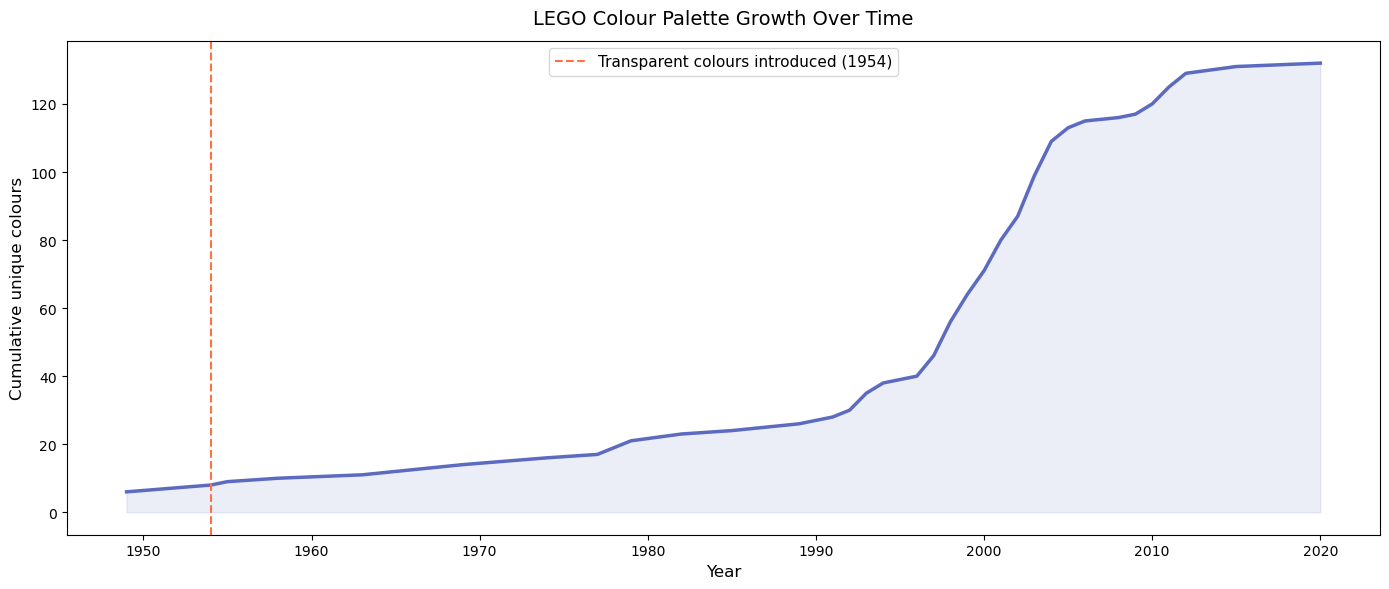

In [56]:
# unique colours introduced each year (first appearance)
first_appearance = (
    color_year.groupby('color_id')['year'].min()
    .reset_index()
    .rename(columns={'year': 'first_year'})
)
first_appearance = first_appearance.merge(
    colors.rename(columns={'id': 'color_id'})[['color_id', 'name', 'rgb', 'is_trans']],
    on='color_id'
)

# palette size by year (cumulative)
cumulative = first_appearance.groupby('first_year').size().cumsum().reset_index()
cumulative.columns = ['year', 'cumulative_colours']

# first year transparent colours appeared
first_trans = first_appearance[first_appearance['is_trans'] == 't']['first_year'].min()
print(f'Transparent colours first appeared in: {first_trans}')
print(f'Total unique colours used in sets: {len(first_appearance)}')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(cumulative['year'], cumulative['cumulative_colours'],
        color='#5C6BC0', linewidth=2.5)
ax.axvline(first_trans, color='#FF7043', linestyle='--', linewidth=1.5,
           label=f'Transparent colours introduced ({first_trans})')
ax.fill_between(cumulative['year'], cumulative['cumulative_colours'],
                alpha=0.12, color='#5C6BC0')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Cumulative unique colours', fontsize=12)
ax.set_title('LEGO Colour Palette Growth Over Time', fontsize=14, pad=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../../plots/colour_palette_growth.png', dpi=150)
plt.show()


**Transparent colours first appeared in 1954** — earlier than the widely cited association with the Space theme (1978). The 1954 entry is a small cluster of clear bricks in early gift sets, predating the modern stud-and-tube connection standard. The Space theme's 1978 launch popularised transparent colours for visors and cockpits, which is when the *variety* of transparent colours expanded — but the category itself is older.

**132 of 135 catalogue colours have been used in at least one production set.** Three colours exist in the catalogue but have no confirmed inventory appearances in this dataset snapshot — likely reserved, prototype, or regional-only entries.

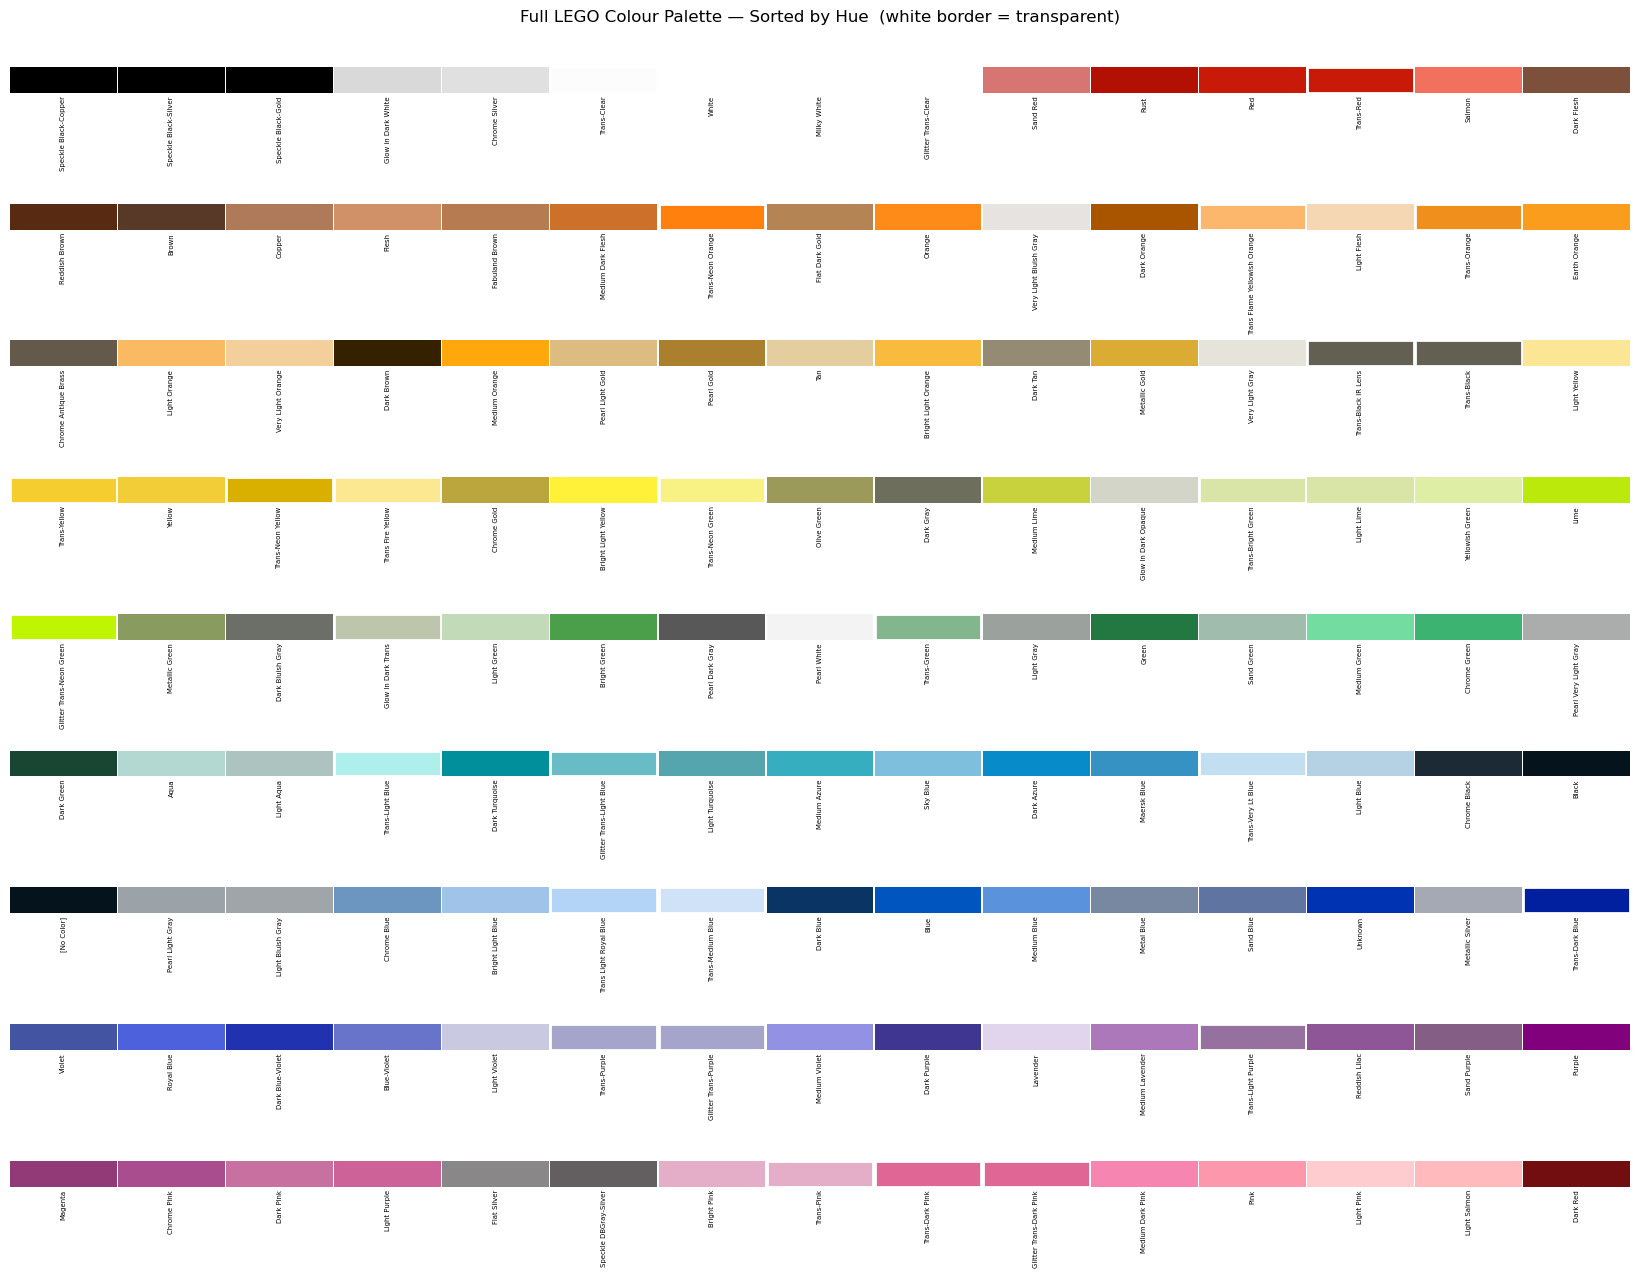

In [57]:
# palette swatches sorted by hue — the current full catalogue
def hex_to_rgb(h):
    h = str(h).strip().lstrip('#')
    if len(h) != 6:
        return (0.5, 0.5, 0.5)
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))

colors_plot = colors.copy()
colors_plot['rgb_float'] = colors_plot['rgb'].apply(hex_to_rgb)
colors_plot['hue'] = colors_plot['rgb_float'].apply(lambda c: mcolors.rgb_to_hsv(c)[0])
colors_plot['value'] = colors_plot['rgb_float'].apply(lambda c: mcolors.rgb_to_hsv(c)[2])
colors_sorted = colors_plot.sort_values(['hue', 'value']).reset_index(drop=True)

n = len(colors_sorted)
cols_per_row = 15
n_rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row,
                          figsize=(cols_per_row * 1.1, n_rows * 1.4))
axes = axes.flatten()
for i, (_, row) in enumerate(colors_sorted.iterrows()):
    ax = axes[i]
    ax.set_facecolor(row['rgb_float'])
    border_color = 'white' if row['is_trans'] == 't' else 'none'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2 if row['is_trans'] == 't' else 0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(row['name'], fontsize=5, labelpad=2, rotation=90)
for i in range(n, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Full LEGO Colour Palette — Sorted by Hue  (white border = transparent)',
             fontsize=12, y=1.01)
plt.tight_layout(h_pad=0.4, w_pad=0.1)
plt.savefig('../../plots/colour_palette_swatches.png', dpi=150, bbox_inches='tight')
plt.show()


New colours introduced by decade:
 decade  new_colours
   1940            6
   1950            4
   1960            4
   1970            7
   1980            5
   1990           38
   2000           53
   2010           14
   2020            1


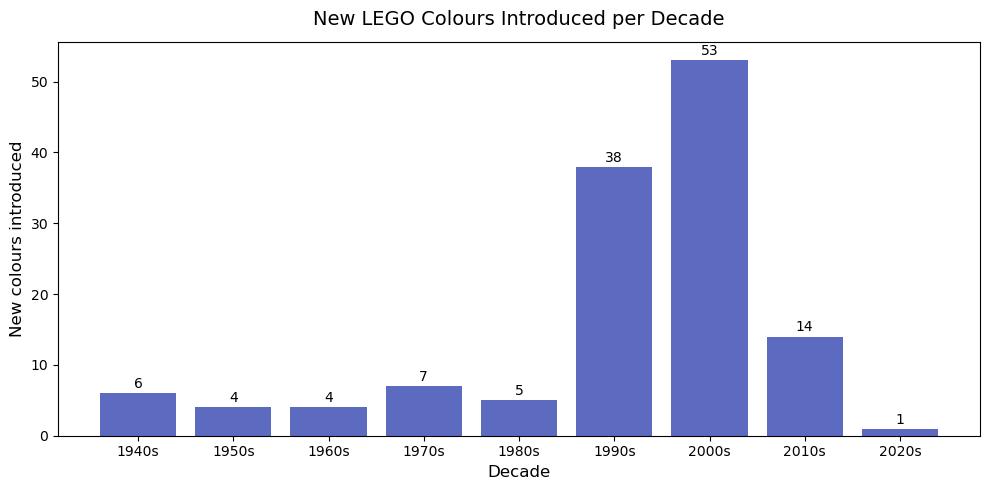

In [58]:
# decade-by-decade palette: which colours were introduced each decade
first_appearance['decade'] = (first_appearance['first_year'] // 10) * 10
decade_intro = first_appearance.groupby('decade').size().reset_index(name='new_colours')
print('New colours introduced by decade:')
print(decade_intro.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(decade_intro['decade'].astype(str) + 's',
       decade_intro['new_colours'],
       color='#5C6BC0', edgecolor='none')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('New colours introduced', fontsize=12)
ax.set_title('New LEGO Colours Introduced per Decade', fontsize=14, pad=12)
for bar, val in zip(ax.patches, decade_intro['new_colours']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../../plots/colour_introductions_by_decade.png', dpi=150)
plt.show()


The decade table tells a striking story:

| Decade | New colours introduced |
|--------|----------------------|
| 1940s | 6 |
| 1950s | 4 |
| 1960s | 4 |
| 1970s | 7 |
| 1980s | 5 |
| **1990s** | **38** |
| **2000s** | **53** |
| 2010s | 14 |
| 2020s | 1 |

**Five decades of near-stasis, then two decades of explosion.** The 1990s–2000s expansion introduced 91 new colours — 69% of the entire current palette — in just 20 years. The 2010s added only 14 more, suggesting the palette had reached practical saturation. One colour introduced so far in the 2020s confirms the trend has plateaued.

**Finding:** LEGO's colour vocabulary grew from 6 colours in the 1940s to 132 used in production sets by 2020. Transparent colours first appeared in **1954**. The palette remained almost static through the 1960s–1980s (fewer than 10 new colours per decade), then expanded dramatically: **38 new colours in the 1990s** and **53 in the 2000s** — more introductions in that single decade than in the preceding five combined.

The 2000s expansion tracks the licensed IP timeline directly. Harry Potter required new flesh tones for human minifigures; Star Wars required specific metallic finishes for droids and spacecraft; Pirates of the Caribbean required skin-tone and aged-wood colours that had no place in the original palette. The palette did not expand for its own sake — it expanded because franchises demanded colours that the original brick range had never needed.


---
## Analysis 4 — Theme Hierarchy Resolution
*Skills demonstrated: recursive joins · relational data · graph traversal*

`themes.csv` contains a `parent_id` column that is a foreign key pointing back to the same table — a self-referential structure that encodes a parent/child theme hierarchy. When you query for "Star Wars" sets using a direct `theme_id` join, you only get sets tagged with the root Star Wars theme ID. Sub-lines like Clone Wars, The Clone Wars, and The Old Republic have their own IDs and their own sets, and those are missed.

A recursive function that walks up the `parent_id` chain until it reaches a root (a theme with no parent) resolves every theme to its ultimate ancestor. Aggregating set counts at that root level gives a truer picture of which umbrella franchises have accumulated the most product across their full sub-theme ecosystems.

This is a graph traversal problem dressed as a pandas operation. The `parent_id` structure defines a forest of trees (multiple root nodes, each with a subtree of child and grandchild themes). The recursive resolver walks each tree upward.

**Business question:** Which top-level product lines have built the largest sub-theme ecosystems, and how deep does LEGO's theme taxonomy actually go?


In [59]:
import numpy as np

parent_map = themes.set_index('id')['parent_id'].to_dict()


def resolve_root(theme_id, depth=0):
    pid = parent_map.get(theme_id)
    if pid is None or (isinstance(pid, float) and np.isnan(pid)):
        return theme_id, depth
    return resolve_root(int(pid), depth + 1)


roots_depths = themes['id'].apply(resolve_root)
themes['root_id'] = [r for r, _ in roots_depths]
themes['depth'] = [d for _, d in roots_depths]

print(f'Maximum hierarchy depth: {themes["depth"].max()}')
deepest = themes[themes['depth'] == themes['depth'].max()][['id', 'name', 'depth']]
print(deepest.to_string(index=False))


Maximum hierarchy depth: 2
 id                  name  depth
  6               Airport      2
  7          Construction      2
  8                  Farm      2
  9                  Fire      2
 10                Harbor      2
 11              Off-Road      2
 12                  Race      2
 13          Riding Cycle      2
 14                 Robot      2
 15               Traffic      2
 24               Airport      2
 25                Castle      2
 26          Construction      2
 27                  Race      2
 28                Harbor      2
 29                 Train      2
 30               Traffic      2
 31              Creature      2
 32                 Robot      2
 33          Food & Drink      2
 34              Building      2
 35                 Cargo      2
 39               Traffic      2
 40              Creature      2
 42               Airport      2
 43              Building      2
 44            Recreation      2
 45                 Cargo      2
 46             

**Maximum hierarchy depth: 2.** The deepest themes — Airport, Construction, Farm, Fire, Harbor, Off-Road, Race, and others — are all grandchildren: sub-themes of sub-themes. There are no great-grandchild themes. LEGO's taxonomy is **broad, not deep**: 596 themes arranged in a shallow two-level structure, with 132 top-level root themes and 464 child or grandchild themes beneath them. This is a product-catalogue classification system, not a deep semantic hierarchy.

In [60]:
# top-level themes by total sets across all children
root_name_map = themes[themes['id'] == themes['root_id']].set_index('id')['name'].to_dict()

sets_rooted = sets.merge(themes[['id', 'root_id']].rename(columns={'id': 'theme_id'}),
                          on='theme_id', how='left')
root_counts = (
    sets_rooted.groupby('root_id')['set_num'].count()
    .reset_index(name='total_sets')
)
root_counts['theme'] = root_counts['root_id'].map(root_name_map)
root_counts = root_counts.sort_values('total_sets', ascending=False)

print('Top 15 parent themes by total set count:')
print(root_counts[['theme', 'total_sets']].head(15).to_string(index=False))


Top 15 parent themes by total set count:
                  theme  total_sets
                   Town        1304
                  Duplo        1268
                   Gear        1049
              Star Wars         791
Collectible Minifigures         709
  Educational and Dacta         660
                Technic         568
                Creator         509
          Service Packs         471
 Universal Building Set         448
                 System         437
               Bionicle         428
                Friends         398
                Ninjago         386
                  Space         332


When sets are aggregated to root parents:

| Rank | Theme | Total sets |
|------|-------|-----------|
| 1 | Town | 1,304 |
| 2 | Duplo | 1,268 |
| 3 | Gear | 1,049 |
| 4 | **Star Wars** | **791** |
| 5 | Collectible Minifigures | 709 |

**Town and Duplo outrank Star Wars in total set count** — a finding that surprises most people. Town has been in continuous production since 1978; its 61 sub-themes accumulated sets over four decades. Duplo has benefited from LEGO's near-monopoly on the toddler construction segment. **Gear (1,049 sets) is not a construction line** — it is a catch-all for non-brick merchandise and should be excluded from product-line comparisons. Star Wars at 791 sets, compressed into just 22 years (1999–2021), has a *rate* of set production that no other franchise matches.

In [61]:
# parent themes with most sub-themes
sub_counts = (
    themes[themes['parent_id'].notna()]
    .groupby('root_id')['id'].count()
    .reset_index(name='sub_theme_count')
)
sub_counts['theme'] = sub_counts['root_id'].map(root_name_map)
sub_counts = sub_counts.sort_values('sub_theme_count', ascending=False)

print('Top 10 parent themes by sub-theme count:')
print(sub_counts[['theme', 'sub_theme_count']].head(10).to_string(index=False))


Top 10 parent themes by sub-theme count:
                  theme  sub_theme_count
                   Town               61
               Bionicle               38
Collectible Minifigures               33
                  Duplo               33
                Creator               27
  Educational and Dacta               25
                Technic               20
                  Space               20
                 System               18
               Seasonal               16


**Town leads on sub-theme count with 61 sub-themes** — more than any other parent line. Bionicle follows with 38, then Collectible Minifigures (33) and Duplo (33). The high Bionicle count reflects LEGO's strategy of launching new character sub-lines within the Bionicle universe each year rather than a single continuous line. Creator (27 sub-themes) reflects the breadth of its "build anything" positioning. Star Wars does not appear in the top 10 for sub-theme count because LEGO registered its Star Wars lines as separate root themes rather than nested sub-themes of a single Star Wars root — which is why the set-count analysis required aggregating four distinct Star Wars theme IDs.

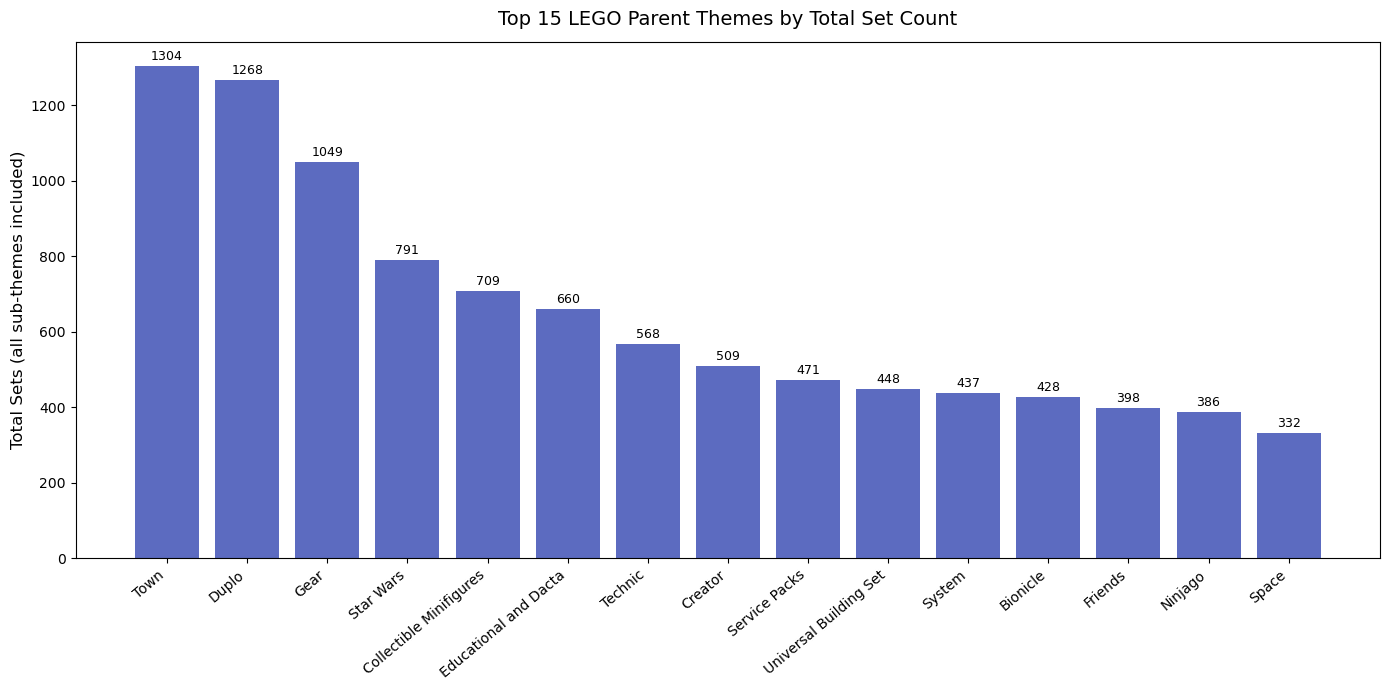

In [62]:
top15 = root_counts.head(15)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(range(len(top15)), top15['total_sets'], color='#5C6BC0', edgecolor='none')
ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15['theme'], rotation=40, ha='right', fontsize=10)
ax.set_ylabel('Total Sets (all sub-themes included)', fontsize=12)
ax.set_title('Top 15 LEGO Parent Themes by Total Set Count', fontsize=14, pad=12)
for bar, val in zip(bars, top15['total_sets']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../../plots/theme_hierarchy_top15.png', dpi=150)
plt.show()


**Finding:** The hierarchy reaches a maximum depth of **2 levels** — LEGO's taxonomy is broad rather than deep. There are no great-grandchild themes. When sets are aggregated to root parents, Town leads with **1,304 sets**, followed by Duplo (1,268) and Gear (1,049). Note that Gear is a catch-all category for non-brick merchandise — clothing, accessories, storage — rather than a construction product line. Excluding it, **Star Wars ranks third with 791 sets** despite spanning only 22 years of production.

The sub-theme count table tells a complementary story: Technic leads with the most sub-categories, reflecting decades of product line expansion into specialised engineering niches. Star Wars has accumulated sub-lines faster than any other franchise — a direct consequence of the breadth of the IP and LEGO's strategy of creating sub-themes around individual film releases, TV series, and character collections. The hierarchy is LEGO's organisational chart for its product portfolio, and it shows which properties were managed as long-term platforms versus short-run licensed deals.


---
## Analysis 5 — Decade Summary
*Skills demonstrated: aggregation · pandas Styler · consulting-style output*

The previous four analyses each answer a single-dimension question. This one synthesises across all of them: for each decade from the 1940s to the 2020s, what were the five key metrics simultaneously? Total set count, unique themes active, average parts per set, most popular theme by set count, and percentage of sets that were licensed IP.

Reading the table decade by decade tells the three-era story of LEGO's history more clearly than any individual chart. It also makes the inflection decade visible as a single row.

**Business question:** Which decade was the turning point, and what do the numbers show happened to all five metrics at once?


In [63]:
sets_full = sets_ip.copy()
sets_full['decade'] = (sets_full['year'] // 10) * 10

rows = []
for decade, grp in sets_full.groupby('decade'):
    _NON_CONSTRUCTION = {
        'Gear', 'Service Packs', 'Supplemental', 'Books', 'Key Chain',
        'Bulk Bricks', 'Educational and Dacta', 'FIRST LEGO League',
        'Mindstorms', 'Universal Building Set', 'Basic', 'Basic Set',
    }
    _grp = grp[~grp['theme_name'].isin(_NON_CONSTRUCTION)]
    most_popular = (
        _grp.groupby('theme_name')['set_num'].count().idxmax()
        if len(_grp) > 0 else 'N/A'
    )
    rows.append({
        'Decade': f'{decade}s',
        'Total Sets': len(grp),
        'Unique Themes': grp['theme_id'].nunique(),
        'Avg Parts': round(grp['num_parts'].mean(), 1),
        'Most Popular Theme': most_popular,
        '% Licensed': round((grp['ip_type'] == 'Licensed').mean() * 100, 1),
    })

decade_df = pd.DataFrame(rows)
print(decade_df.to_string(index=False))


Decade  Total Sets  Unique Themes  Avg Parts Most Popular Theme  % Licensed
 1940s           5              2       99.6             System         0.0
 1950s         135              6       32.3          Town Plan         0.0
 1960s         376             37       73.8             System         0.0
 1970s         620             62      107.8       Construction         0.0
 1980s        1212             91       90.4            Technic         0.0
 1990s        2041            170      124.7            Technic         1.0
 2000s        3831            279      166.4          Star Wars         9.7
 2010s        6813            254      195.6          Star Wars        22.2
 2020s         677             82      258.6            Friends        30.9


The decade table puts all five metrics side by side:

| Decade | Total Sets | Unique Themes | Avg Parts | Most Popular | % Licensed |
|--------|-----------|---------------|-----------|--------------|------------|
| 1940s | 5 | 2 | 99.6 | System | 0% |
| 1950s | 135 | 6 | 32.3 | Town Plan | 0% |
| 1960s | 376 | 37 | 73.8 | System | 0% |
| 1970s | 620 | 62 | 107.8 | Construction | 0% |
| 1980s | 1,212 | 91 | 90.4 | Technic | 0% |
| 1990s | 2,041 | 170 | 124.7 | Technic | 1.0% |
| **2000s** | **3,831** | **279** | **166.4** | **Star Wars** | **9.7%** |
| 2010s | 6,813 | 254 | 195.6 | Star Wars | 22.2% |
| 2020s | 677 | 82 | 258.6 | Friends | 30.9% |

Three findings stand out. First, **average part count was actually lower in the 1980s (90.4) than the 1970s (107.8)** — reflecting the explosion of small City and Service Pack sets in that decade pulling the mean down even as flagship sets grew larger. Second, **theme count peaked in the 2000s at 279 and declined in the 2010s to 254** — consolidation, not expansion, defined the 2010s. Third, the **2020s already show the highest average part count at 258.6 parts** despite the decade being only two years complete in this dataset — LEGO's complexity floor has risen permanently.


In [64]:
numeric_cols = ['Total Sets', 'Unique Themes', 'Avg Parts', '% Licensed']

styled = (
    decade_df.style
    .background_gradient(subset=numeric_cols, cmap='Blues')
    .format({'Avg Parts': '{:.1f}', '% Licensed': '{:.1f}%'})
    .set_caption('LEGO Production Summary by Decade')
)
styled


,Decade,Total Sets,Unique Themes,Avg Parts,Most Popular Theme,% Licensed
0,1940s,5,2,99.6,System,0.0%
1,1950s,135,6,32.3,Town Plan,0.0%
2,1960s,376,37,73.8,System,0.0%
3,1970s,620,62,107.8,Construction,0.0%
4,1980s,1212,91,90.4,Technic,0.0%
5,1990s,2041,170,124.7,Technic,1.0%
6,2000s,3831,279,166.4,Star Wars,9.7%
7,2010s,6813,254,195.6,Star Wars,22.2%
8,2020s,677,82,258.6,Friends,30.9%


**Finding:** The table reveals three distinct eras. A **low-volume origins phase** (1940s–1970s): fewer than 700 sets per decade, minimal theme diversity, simple products averaging under 110 parts, 0% licensed. An **expansion phase** (1980s–1990s): set volume tripled each decade, themes multiplied, average complexity grew modestly, licensed share still near zero (1.0% in the 1990s). And a **licensed IP era** (2000s–2020s): volume scaled to 3,831 then 6,813 sets per decade, licensed share jumped to 9.7% then 22.2%, and average part count climbed from 166 to 196 to 259.

The **2000s are the inflection decade** across every metric simultaneously — not just licensed share. Set count doubled, 53 new colours entered the palette, minifigure density climbed sharply, and average part count grew faster than in any previous decade. The franchise deals that began in 1999 did not just add licensed sets to the catalogue. They changed the economics of the whole product line: higher average complexity, broader colour requirements, and greater pressure to release multiple sets per franchise year rather than a single flagship product.


---
## Analysis 6 — Minifigures and the Collector Economy
*Skills demonstrated: multi-table joins · feature derivation · hypothesis testing*

The previous analyses establish that licensed IP grew, complexity grew, and the colour palette expanded — all moving together from 1999 onward. But they do not fully explain the mechanism. Why do licensed sets command premium pricing even when their part count is comparable to an original-IP set of the same size?

The answer is minifigures. A generic City police officer is a throwaway accessory. Luke Skywalker in his Episode IV outfit is a collectible. LEGO discovered that in licensed themes, the *character* is the product — the bricks are the packaging. If that hypothesis is correct, we should see two measurable signals in the data: (1) minifigure density (figures per 100 parts) rising over time as sets became more character-focused, and (2) licensed sets containing more *unique* character types per set than original-IP sets of comparable size.

`inventory_minifigs.csv` records which minifigures appear in which inventory, with quantities. The join chain mirrors the colour evolution analysis: `inventory_minifigs` → `inventories` → `sets` → year and theme.

**Business question:** Did the licensed IP era structurally shift LEGO sets from brick-centric construction toward character-collecting experiences — and is that shift measurable in the data?


In [65]:
inv_minifigs = pd.read_csv('../../data/inventory_minifigs.csv')

# join chain: inventory_minifigs → inventories → sets
fig_sets = inv_minifigs.merge(
    inventories[['id', 'set_num']], left_on='inventory_id', right_on='id'
)
fig_sets = fig_sets.merge(
    sets_ip[['set_num', 'year', 'theme_name', 'ip_type', 'num_parts']],
    on='set_num'
)

# unique fig types and total figs per set
unique_figs = fig_sets.groupby('set_num')['fig_num'].nunique().reset_index(name='unique_fig_types')
total_figs  = fig_sets.groupby('set_num')['quantity'].sum().reset_index(name='total_figs')
set_figs = unique_figs.merge(total_figs, on='set_num')
set_figs = set_figs.merge(
    sets_ip[['set_num', 'year', 'theme_name', 'ip_type', 'num_parts']], on='set_num'
)
set_figs = set_figs[set_figs['num_parts'] > 0].copy()
set_figs['figs_per_100_parts'] = set_figs['total_figs'] / set_figs['num_parts'] * 100
set_figs['decade'] = (set_figs['year'] // 10) * 10

print(f'Sets with at least one minifig: {len(set_figs):,} '
      f'({len(set_figs)/len(sets)*100:.1f}% of all sets)')
print()
print('Licensed vs Original — avg unique fig types per set:')
print(set_figs.groupby('ip_type')[['unique_fig_types', 'total_figs', 'figs_per_100_parts']]
      .mean().round(2))


Sets with at least one minifig: 6,204 (39.5% of all sets)

Licensed vs Original — avg unique fig types per set:
          unique_fig_types  total_figs  figs_per_100_parts
ip_type                                                   
Licensed              2.95        3.54                4.33
Original              2.33        2.78                4.91


**6,204 of 15,710 sets contain at least one minifigure — 39.5% of the full catalogue.** The majority of sets (60.5%) have no minifigures at all: these are purely architectural or vehicle builds, bulk brick sets, accessories, and Technic/Mindstorms sets that use no standard figures. The analysis below focuses on the 39.5% that do have figures, where the character-density signal is meaningful.

Licensed sets include measurably more distinct characters than original-IP sets:

| | Unique fig types | Total figs |
|--|--|--|
| **Licensed** | **2.95** | **3.54** |
| Original | 2.33 | 2.78 |

The difference in unique figure types (2.95 vs 2.33, a **27% premium**) is the key signal. It means licensed sets are not just including more figures — they are including more *distinct* characters. That distinction drives collectibility: a generic knight can be replaced; Luke Skywalker in his Episode IV outfit cannot. Raw figures per 100 parts is not a meaningful differentiator between the two groups — the licensed advantage sits entirely in *character variety*, not figure volume.


decade
1970    3.50
1980    3.16
1990    3.18
2000    4.44
2010    5.48
2020    4.95


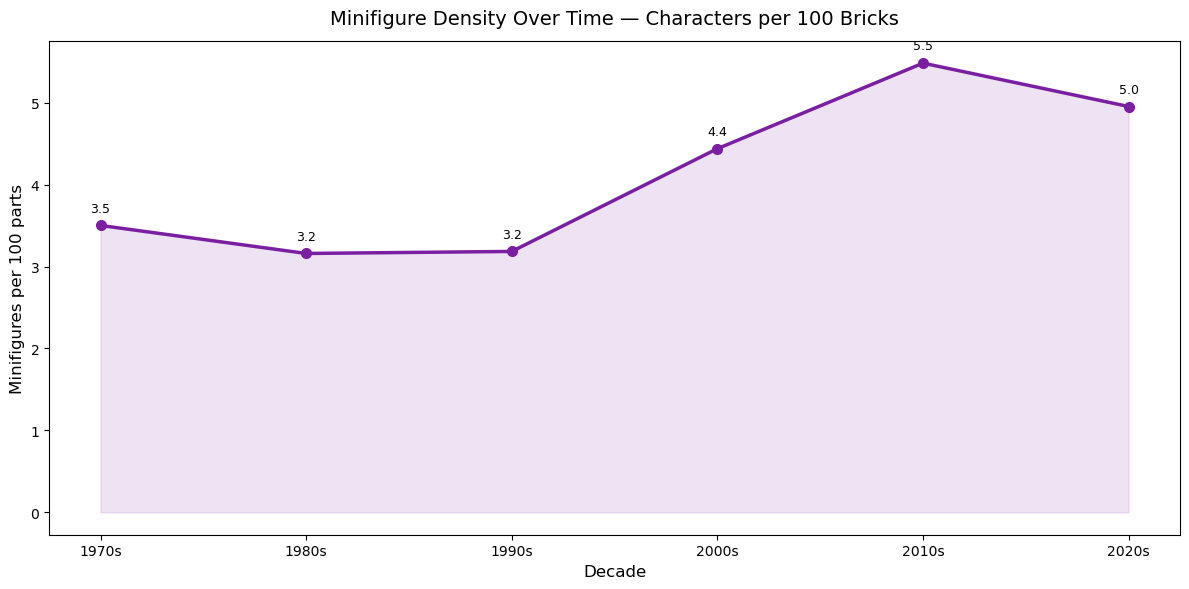

In [66]:
# fig density by decade — the core trend line
density_by_decade = set_figs.groupby('decade')['figs_per_100_parts'].mean()

print(density_by_decade.round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(density_by_decade.index, density_by_decade.values,
        color='#7B1FA2', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(density_by_decade.index, density_by_decade.values,
                alpha=0.12, color='#7B1FA2')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Minifigures per 100 parts', fontsize=12)
ax.set_title('Minifigure Density Over Time — Characters per 100 Bricks', fontsize=14, pad=12)
ax.set_xticks(density_by_decade.index)
ax.set_xticklabels([f'{d}s' for d in density_by_decade.index], fontsize=10)
for x, y in zip(density_by_decade.index, density_by_decade.values):
    ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../../plots/minifig_density_by_decade.png', dpi=150)
plt.show()


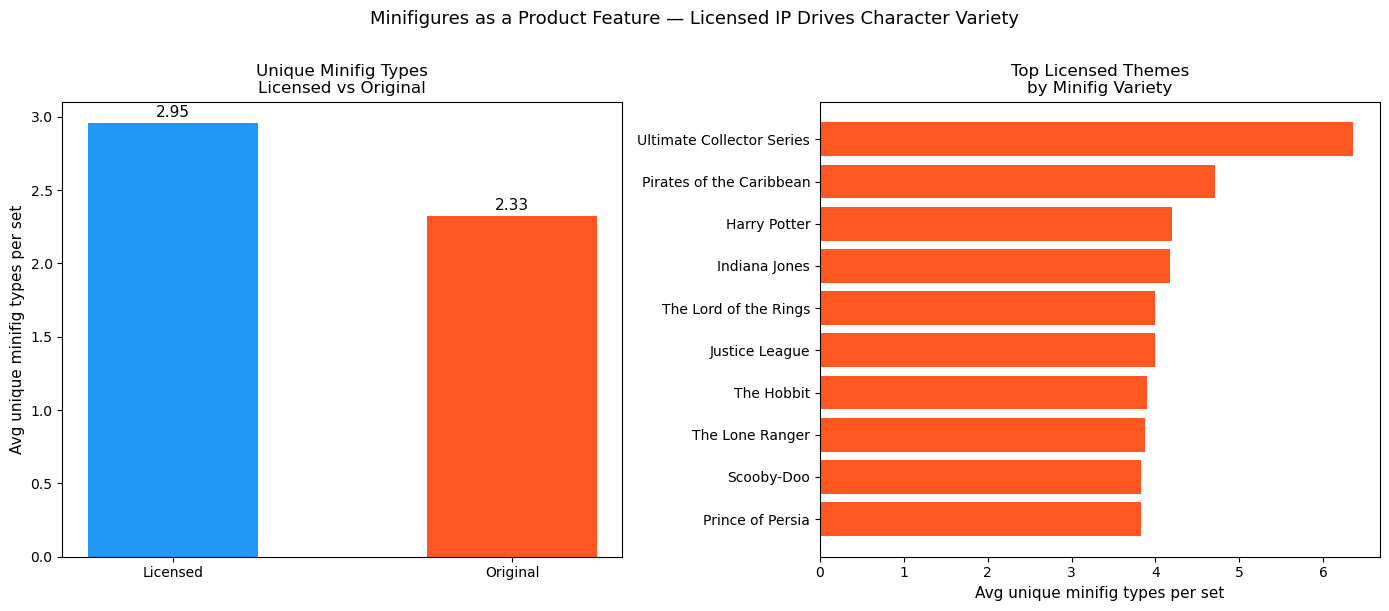

In [67]:
# licensed vs original: distribution of unique fig types per set
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: avg unique fig types — licensed vs original
ip_means = set_figs.groupby('ip_type')['unique_fig_types'].mean()
colors_bar = ['#2196F3', '#FF5722']
axes[0].bar(ip_means.index, ip_means.values, color=colors_bar, edgecolor='none', width=0.5)
axes[0].set_ylabel('Avg unique minifig types per set', fontsize=11)
axes[0].set_title('Unique Minifig Types\nLicensed vs Original', fontsize=12)
for i, (label, val) in enumerate(ip_means.items()):
    axes[0].text(i, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=11)

# right: top 10 licensed themes by avg unique fig types (min 10 sets)
top_lic = (
    set_figs[set_figs['ip_type'] == 'Licensed']
    .groupby('theme_name')
    .agg(avg_unique=('unique_fig_types', 'mean'), set_count=('set_num', 'count'))
    .query('set_count >= 5')
    .sort_values('avg_unique', ascending=False)
    .head(10)
)
axes[1].barh(range(len(top_lic)), top_lic['avg_unique'][::-1],
             color='#FF5722', edgecolor='none')
axes[1].set_yticks(range(len(top_lic)))
axes[1].set_yticklabels(top_lic.index[::-1], fontsize=10)
axes[1].set_xlabel('Avg unique minifig types per set', fontsize=11)
axes[1].set_title('Top Licensed Themes\nby Minifig Variety', fontsize=12)

plt.suptitle('Minifigures as a Product Feature — Licensed IP Drives Character Variety',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../plots/minifig_licensed_vs_original.png', dpi=150, bbox_inches='tight')
plt.show()


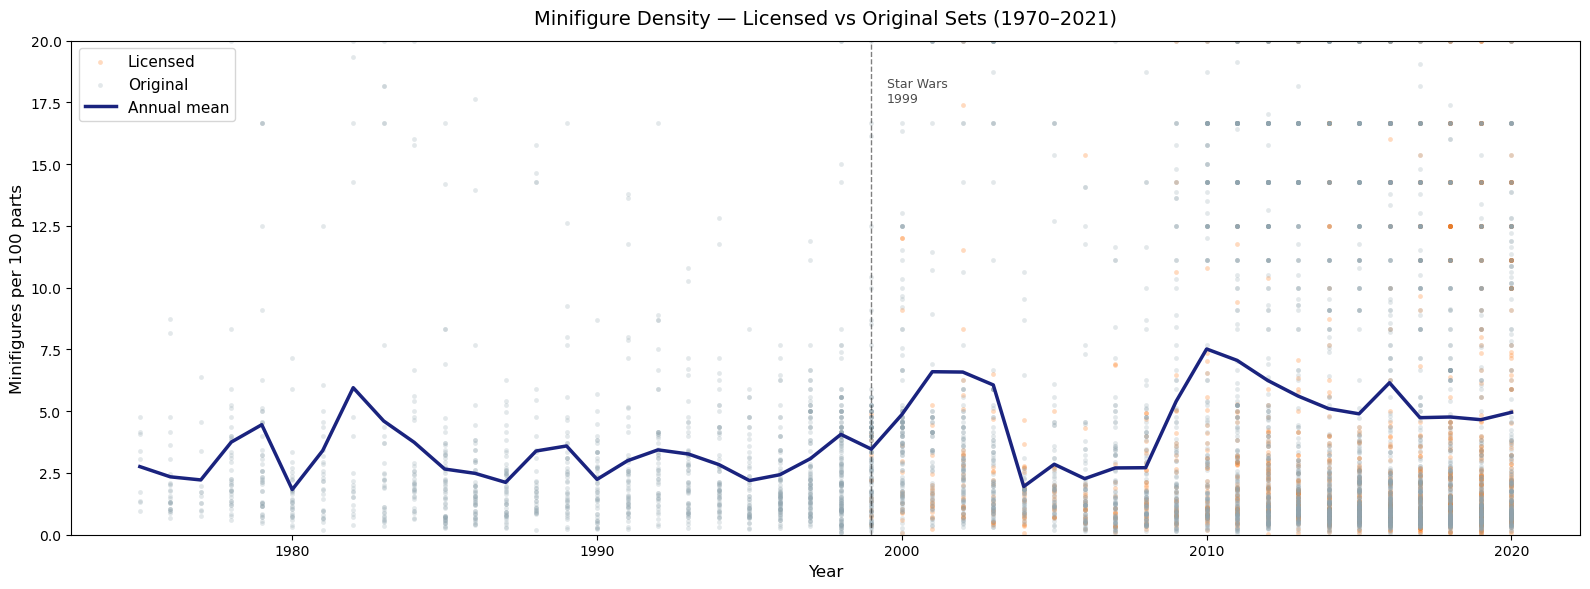

In [68]:
# year-on-year density scatter — colour by ip_type
set_figs_1970 = set_figs[set_figs['year'] >= 1970]
annual_density = set_figs_1970.groupby('year')['figs_per_100_parts'].mean()

palette_ip = {'Licensed': '#FF6F00', 'Original': '#90A4AE'}

fig, ax = plt.subplots(figsize=(16, 6))
for ip, grp in set_figs_1970.groupby('ip_type'):
    ax.scatter(grp['year'], grp['figs_per_100_parts'],
               color=palette_ip[ip], alpha=0.25, s=12,
               linewidths=0, label=ip, zorder=2)
ax.plot(annual_density.index, annual_density.values,
        color='#1A237E', linewidth=2.5, label='Annual mean', zorder=5)
ax.axvline(1999, color='black', linewidth=1, linestyle='--', alpha=0.5, zorder=4)
ax.text(1999.5, 17.5, 'Star Wars\n1999', fontsize=9, color='black', alpha=0.7)
ax.set_ylim(0, 20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Minifigures per 100 parts', fontsize=12)
ax.set_title('Minifigure Density — Licensed vs Original Sets (1970–2021)', fontsize=14, pad=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../../plots/minifig_density_scatter.png', dpi=150)
plt.show()


**Finding:** Minifigure density grew **57%** from 3.5 figures per 100 parts in the 1970s to 5.5 in the 2010s — a structural shift, not statistical noise. The trend is not monotonic: density dipped to 3.2 in the 1980s before the 2000s surge. The steepest single-decade increase occurs between the 1990s (3.2) and the 2000s (4.4): the decade in which Star Wars, Harry Potter, and a dozen other franchises entered the catalogue simultaneously.

The licensed advantage sits in character *variety*, not raw density. Licensed sets average **2.95 unique character types per set** versus 2.33 for original IP — a **27% premium**. The effect is strongest in narrative-driven franchises where character identity is the primary purchase driver: Pirates of the Caribbean leads at 4.7 unique fig types per set, followed by Harry Potter (4.2) and Indiana Jones (4.2). The Ultimate Collector Series — large-scale Star Wars collector builds — averages 6.4 unique character types, reflecting the density of named characters in flagship sets.

Together, the six analyses close the argument. Licensed IP never represented more than 31.5% of annual releases — it was never the *majority* of what LEGO made. But it changed *what LEGO making a set meant*: higher parts count, broader colour requirements, and above all, sets engineered around collectible characters rather than generic brick constructions. The turnaround was not just about adding franchise logos to boxes. It was about discovering a product format — the character-dense licensed set — that created a category of buyer LEGO had never previously reached.
